# BIND 3D: Flow Matching vs Stochastic Interpolant — Comprehensive Analysis

Compares 3D FM and SI models on held-out test simulations.

**Tests:**
1. Mass conservation — emulated vs truth per volume
2. 3D Power spectrum — individual halo volumes and catalog mean field
3. 3D Radial profiles — from halo center to box edge
4. In-distribution check — voxel distributions, mass function, scaling relations
5. Parameter sensitivity — field-level response to cosmological parameter variation

**Channels:** `DM_hydro` (0), `Gas` (1), `Stars` (2)
**Volume:** configurable via `CROP_SIZE` (default below: 128^3)
**FM inference stochasticity:** configurable via `FM_PRIOR_TAU` (default below: 0.75)

In [1]:
import sys, os
sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from data_3d import load_file_list_3d, AstroDataset3D, NormStats3D
from train_3d import FlowMatchingLit3D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})
print(f'Device: {device}')

CHANNEL_NAMES = ['DM_hydro', 'Gas', 'Stars']

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Device: cuda


In [31]:
# -- Configuration -------------------------------------------------
DATA_ROOT    = '/mnt/home/mlee1/ceph/train_data_1024/train_3d'
RUNS_DIR     = Path('/mnt/home/mlee1/ceph/fm_runs_3d')
BOX_SIZE     = 6.25    # Mpc/h (full volume side)
CROP_SIZE    = 128     # production setting
N_PIX        = CROP_SIZE
PIX_SIZE     = BOX_SIZE / N_PIX  # Mpc/h per voxel
STAR_THRESH  = 1e-3

# FM stochastic inference control
FM_PRIOR_TAU = 0.75

# Production run names
FM_RUN_NAME  = 'fm3d_prod128'
SI_RUN_NAME  = None  # e.g. 'si3d_sigma05' to include SI baseline

RUNS = [
    ('FM-3D', RUNS_DIR / FM_RUN_NAME),
]
if SI_RUN_NAME is not None:
    RUNS.append(('SI-3D', RUNS_DIR / SI_RUN_NAME))

RUN_COLORS = {'FM-3D': 'tab:blue', 'SI-3D': 'tab:orange'}

N_TEST     = 200   # 3D volumes to evaluate
N_STEPS    = 50
BATCH_SIZE = 2     # 3D batches are memory-heavy
N_WORKERS  = 4
SEED       = 42
TRAIN_FRAC = 0.9

# Reproduce held-out test split
all_test = load_file_list_3d(DATA_ROOT, 'test', TRAIN_FRAC, SEED)
rng = np.random.RandomState(SEED)
test_files = [all_test[i] for i in rng.choice(len(all_test),
                                                min(N_TEST, len(all_test)),
                                                replace=False)]
print(f'Test volumes: {len(test_files)} (from {len(all_test)} total)')
print(f'Configured FM prior temperature: tau={FM_PRIOR_TAU:.2f}')
print('Configured runs:')
for lbl, path in RUNS:
    print(f'  {lbl:<6s} -> {path}')

Test volumes: 200 (from 4080 total)
Configured FM prior temperature: tau=0.75
Configured runs:
  FM-3D  -> /mnt/home/mlee1/ceph/fm_runs_3d/fm3d_prod128


In [3]:
# ── 3D metric definitions ───────────────────────────────────────

def power_spectrum_3d(volume, box_size=6.25):
    """Azimuthally averaged 3D power spectrum.

    Args:
        volume: (D, H, W) array
        box_size: physical side length in Mpc/h
    Returns:
        k_centers: 1D wavenumber array [h/Mpc]
        pk: 1D power spectrum
    """
    N = volume.shape[0]
    fft = np.fft.fftn(volume)
    pk3d = np.abs(fft) ** 2 * (box_size / N) ** 3

    kfreq = np.fft.fftfreq(N, d=box_size / N) * 2 * np.pi
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing='ij')
    kmag = np.sqrt(kx**2 + ky**2 + kz**2)

    k_bins = np.linspace(0, kfreq.max() * np.sqrt(3), N // 2)
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    pk = np.zeros(len(k_centers))
    for i in range(len(k_centers)):
        mask = (kmag >= k_bins[i]) & (kmag < k_bins[i + 1])
        if mask.sum() > 0:
            pk[i] = pk3d[mask].mean()
    return k_centers, pk


def radial_profile_3d(volume, n_bins=32):
    """3D radial profile centred on the volume.

    Args:
        volume: (D, H, W) array
        n_bins: number of radial bins
    Returns:
        r_centers: bin centres in voxels
        profile: mean per bin
    """
    D, H, W = volume.shape
    z, y, x = np.mgrid[:D, :H, :W] - np.array([D/2, H/2, W/2])[:, None, None, None]
    r = np.sqrt(x**2 + y**2 + z**2)
    r_max = min(D, H, W) / 2
    bins = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (bins[:-1] + bins[1:])
    profile = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (r >= bins[i]) & (r < bins[i + 1])
        if mask.sum() > 0:
            profile[i] = volume[mask].mean()
    return r_centers, profile


def batch_power_spectra_3d(volumes, box_size=6.25):
    """(N, D, H, W) → k, pk_mean, pk_std"""
    pks = [power_spectrum_3d(volumes[i], box_size)[1] for i in range(len(volumes))]
    k, _ = power_spectrum_3d(volumes[0], box_size)
    pks = np.stack(pks)
    return k, pks.mean(0), pks.std(0)


def batch_profiles_3d(volumes, n_bins=32):
    """(N, D, H, W) → r, prof_mean, prof_std"""
    profs = [radial_profile_3d(volumes[i], n_bins)[1] for i in range(len(volumes))]
    r, _ = radial_profile_3d(volumes[0], n_bins)
    profs = np.stack(profs)
    return r, profs.mean(0), profs.std(0)

In [32]:
# -- Model loading & inference helpers ----------------------------

def load_run_3d(run_dir):
    run_dir = Path(run_dir)
    ckpt = run_dir / 'checkpoints' / 'last.ckpt'
    if not ckpt.exists():
        raise FileNotFoundError(f'Missing: {ckpt}')
    model = FlowMatchingLit3D.load_from_checkpoint(str(ckpt), map_location=device)
    model.eval().to(device)
    ns = NormStats3D.load(run_dir / 'norm_stats_3d.npz')
    return model, ns


@torch.no_grad()
def fm_sample_with_prior_temp(fm_obj, condition, large_scale, params,
                              n_steps=50, cfg_scale=1.0, prior_temp=1.0):
    """FM sampling with controllable prior temperature: x0 = prior_temp * N(0, I)."""
    fm_obj.model.eval()
    bsz = condition.shape[0]
    spatial = condition.shape[2:]
    device = condition.device

    x = torch.randn(bsz, 3, *spatial, device=device) * prior_temp
    dt = 1.0 / n_steps

    for i in range(n_steps):
        t = torch.full((bsz,), i * dt, device=device)
        inp = torch.cat([x, condition, large_scale], dim=1)

        if cfg_scale != 1.0:
            v_cond = fm_obj.model(inp, t, params)
            v_uncond = fm_obj.model(inp, t, torch.zeros_like(params))
            v = v_uncond + cfg_scale * (v_cond - v_uncond)
        else:
            v = fm_obj.model(inp, t, params)

        x = x + v * dt

    return x


@torch.no_grad()
def generate_predictions_3d(model, ns, files, batch_size=2, n_steps=50, n_workers=4,
                            fm_prior_temp=None):
    """Run 3D inference; return (real, gen) in physical space, plus params."""
    ds = AstroDataset3D(files, ns, crop_size=CROP_SIZE, random_crop=False, augment_flip=False)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=n_workers, pin_memory=True,
                        persistent_workers=(n_workers > 0))
    all_real, all_gen, all_params = [], [], []
    for batch in tqdm(loader, desc='  sampling', leave=False):
        cond   = batch['condition'].to(device)
        ls     = batch['large_scale'].to(device)
        params = batch['params'].to(device)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            use_temp = (fm_prior_temp is not None and
                        model.fm.__class__.__name__ == 'FlowMatching3D')
            if use_temp:
                gen = fm_sample_with_prior_temp(
                    model.fm, cond, ls, params,
                    n_steps=n_steps, prior_temp=fm_prior_temp,
                )
            else:
                gen = model.fm.sample(cond, ls, params, n_steps=n_steps)

        real_np = batch['target'].numpy().copy()
        gen_np  = gen.float().cpu().numpy()
        for arr in (real_np, gen_np):
            for ch in range(3):
                arr[:, ch] = arr[:, ch] * ns.target_std[ch] + ns.target_mean[ch]
                arr[:, ch] = 10.0 ** arr[:, ch] - 1.0
        all_real.append(np.clip(real_np, 0, None))
        all_gen.append(np.clip(gen_np,  0, None))
        all_params.append(batch['params'].numpy())

    return (np.concatenate(all_real),
            np.concatenate(all_gen),
            np.concatenate(all_params))

In [ ]:
# -- Load models and generate predictions -------------------------
results = {}  # label -> {real, gen, params, ns}

for label, run_dir in RUNS:
    if not Path(run_dir).exists():
        print(f'[SKIP] {label} -- {run_dir} not found')
        continue

    print(f'\n=== {label} ===')
    model, ns = load_run_3d(run_dir)

    # Apply FM prior-temperature only for FM models.
    fm_tau = FM_PRIOR_TAU if 'FM' in label else None
    real, gen, params = generate_predictions_3d(
        model, ns, test_files, batch_size=BATCH_SIZE,
        n_steps=N_STEPS, n_workers=N_WORKERS,
        fm_prior_temp=fm_tau,
    )

    results[label] = dict(real=real, gen=gen, params=params, ns=ns, fm_tau=fm_tau)
    del model
    torch.cuda.empty_cache()
    tau_msg = f' | tau={fm_tau:.2f}' if fm_tau is not None else ''
    print(f'  {len(real)} volumes | shape: {real.shape} | real max: {real.max():.2e}{tau_msg}')

if not results:
    raise RuntimeError(
        'No configured runs were found. Set FM_RUN_NAME/SI_RUN_NAME in the configuration cell, '
        'run training, then rerun this notebook from the top.'
    )

ref    = list(results.values())[0]
real   = ref['real']   # (N, 3, CROP_SIZE, CROP_SIZE, CROP_SIZE)
params = ref['params'] # (N, 36)


=== FM-3D ===


  sampling:   0%|          | 0/100 [00:00<?, ?it/s]

  200 volumes | shape: (200, 3, 64, 64, 64) | real max: 2.32e+12

=== SI-3D ===


  sampling:   0%|          | 0/100 [00:00<?, ?it/s]

  200 volumes | shape: (200, 3, 64, 64, 64) | real max: 2.32e+12


## 1. Visual Comparison
Middle slice (z=32) of four example volumes for each channel.

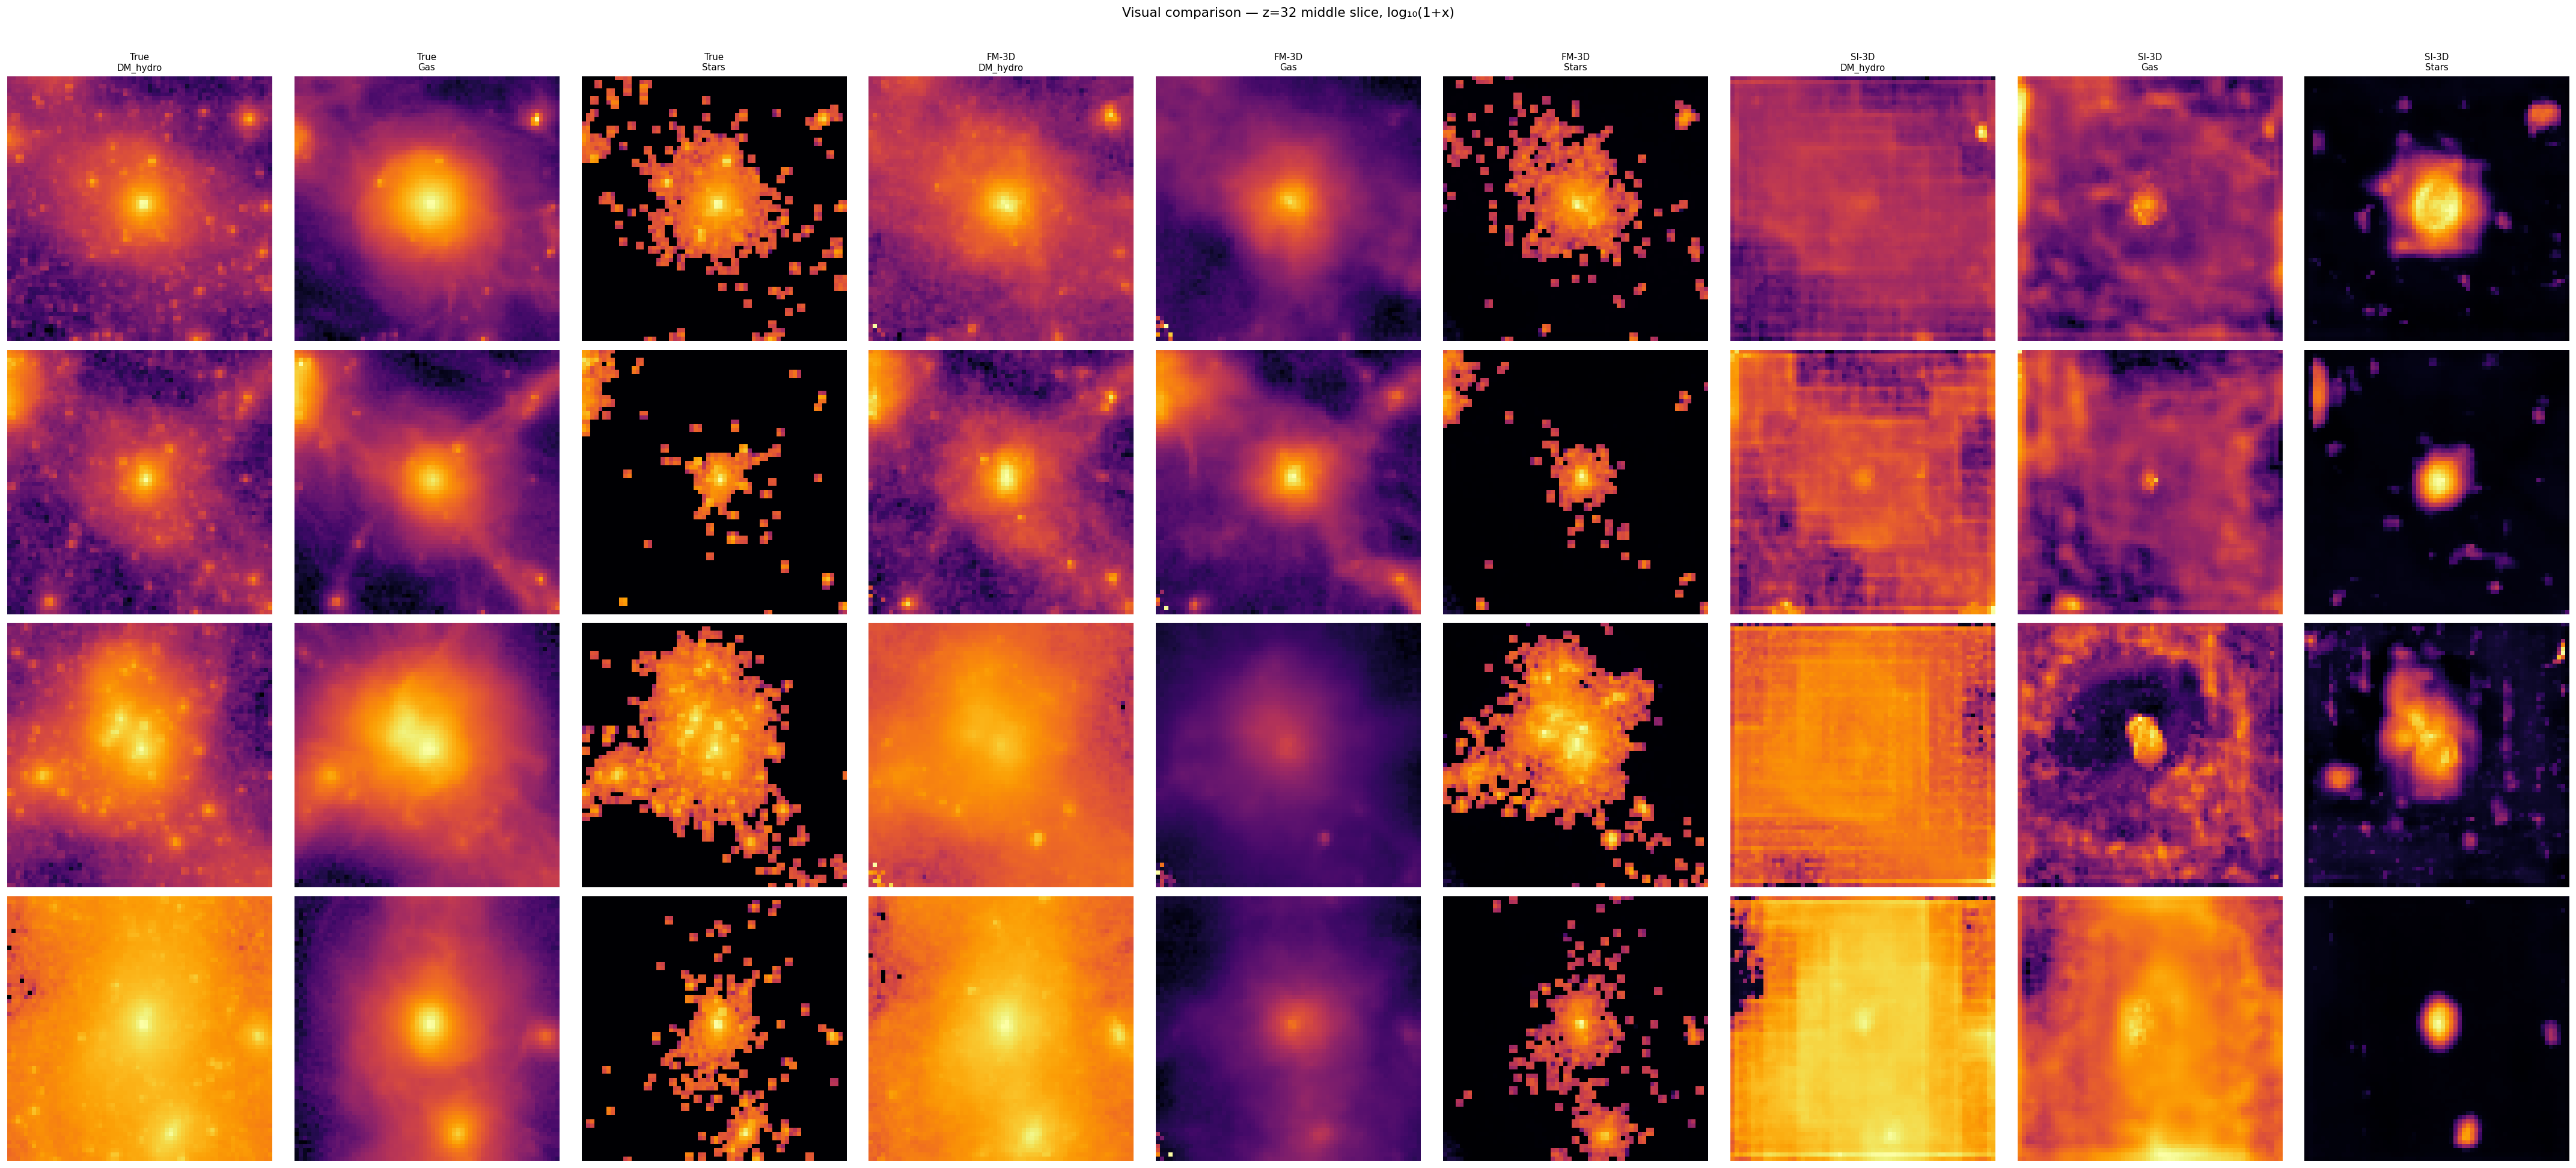

In [18]:
SLICE_Z    = CROP_SIZE // 2
N_SHOW     = 4
run_labels = list(results.keys())
n_cols     = 3 * (1 + len(run_labels))
show_idx   = np.linspace(0, len(real) - 1, N_SHOW, dtype=int)

fig, axes = plt.subplots(N_SHOW, n_cols, figsize=(4 * n_cols, 4 * N_SHOW))
for row, idx in enumerate(show_idx):
    for ch in range(3):
        ax = axes[row, ch]
        slc = real[idx, ch, :, :, :].sum(axis=0)  # max projection along z for better visibility
        ax.imshow(np.log10(slc + 1), cmap='inferno', origin='lower')
        if row == 0: ax.set_title(f'True\n{CHANNEL_NAMES[ch]}', fontsize=9)
        if ch == 0: ax.set_ylabel(f'vol {idx}', fontsize=8)
        ax.axis('off')
        for ri, lbl in enumerate(run_labels):
            col = 3 * (ri + 1) + ch
            ax2 = axes[row, col]
            slc_g = results[lbl]['gen'][idx, ch, :, :, :].sum(axis=0)  # max projection along z for better visibility
            ax2.imshow(np.log10(slc_g + 1), cmap='inferno', origin='lower')
            if row == 0: ax2.set_title(f'{lbl}\n{CHANNEL_NAMES[ch]}', fontsize=9)
            ax2.axis('off')

plt.suptitle(f'Visual comparison — z={SLICE_Z} middle slice, log₁₀(1+x)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

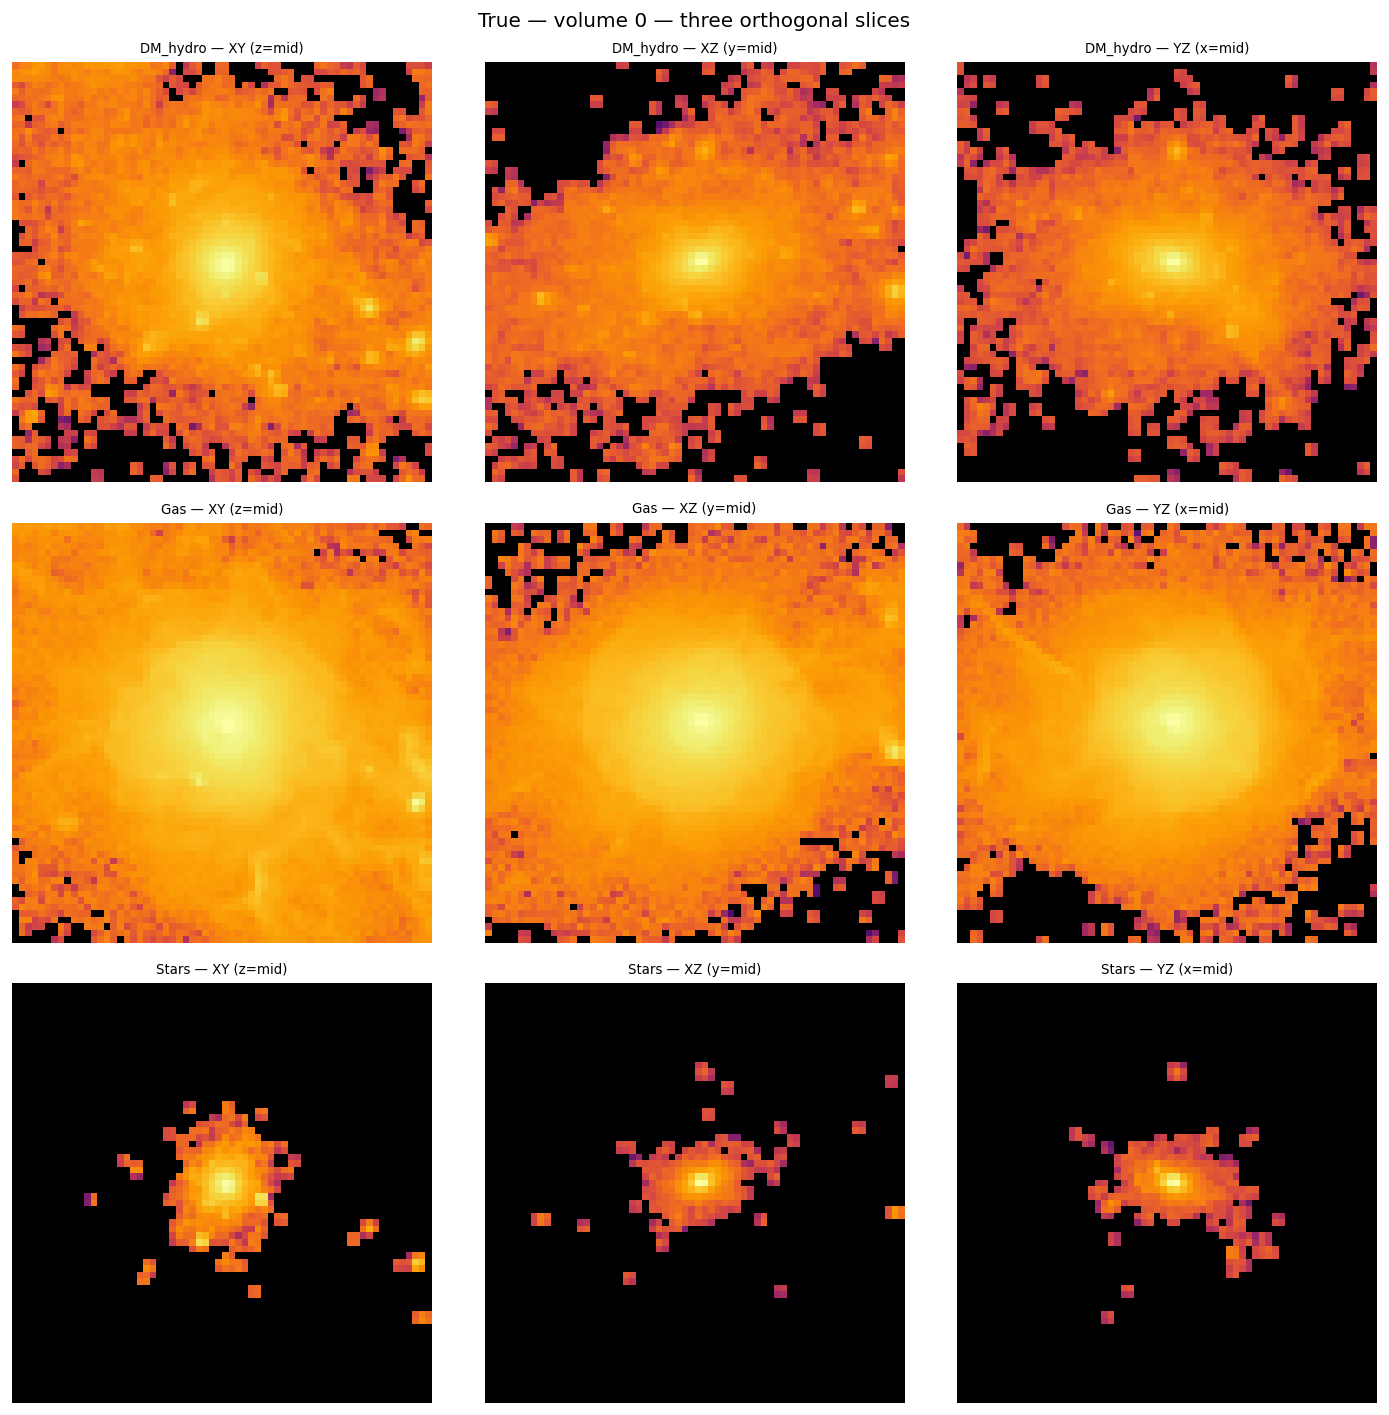

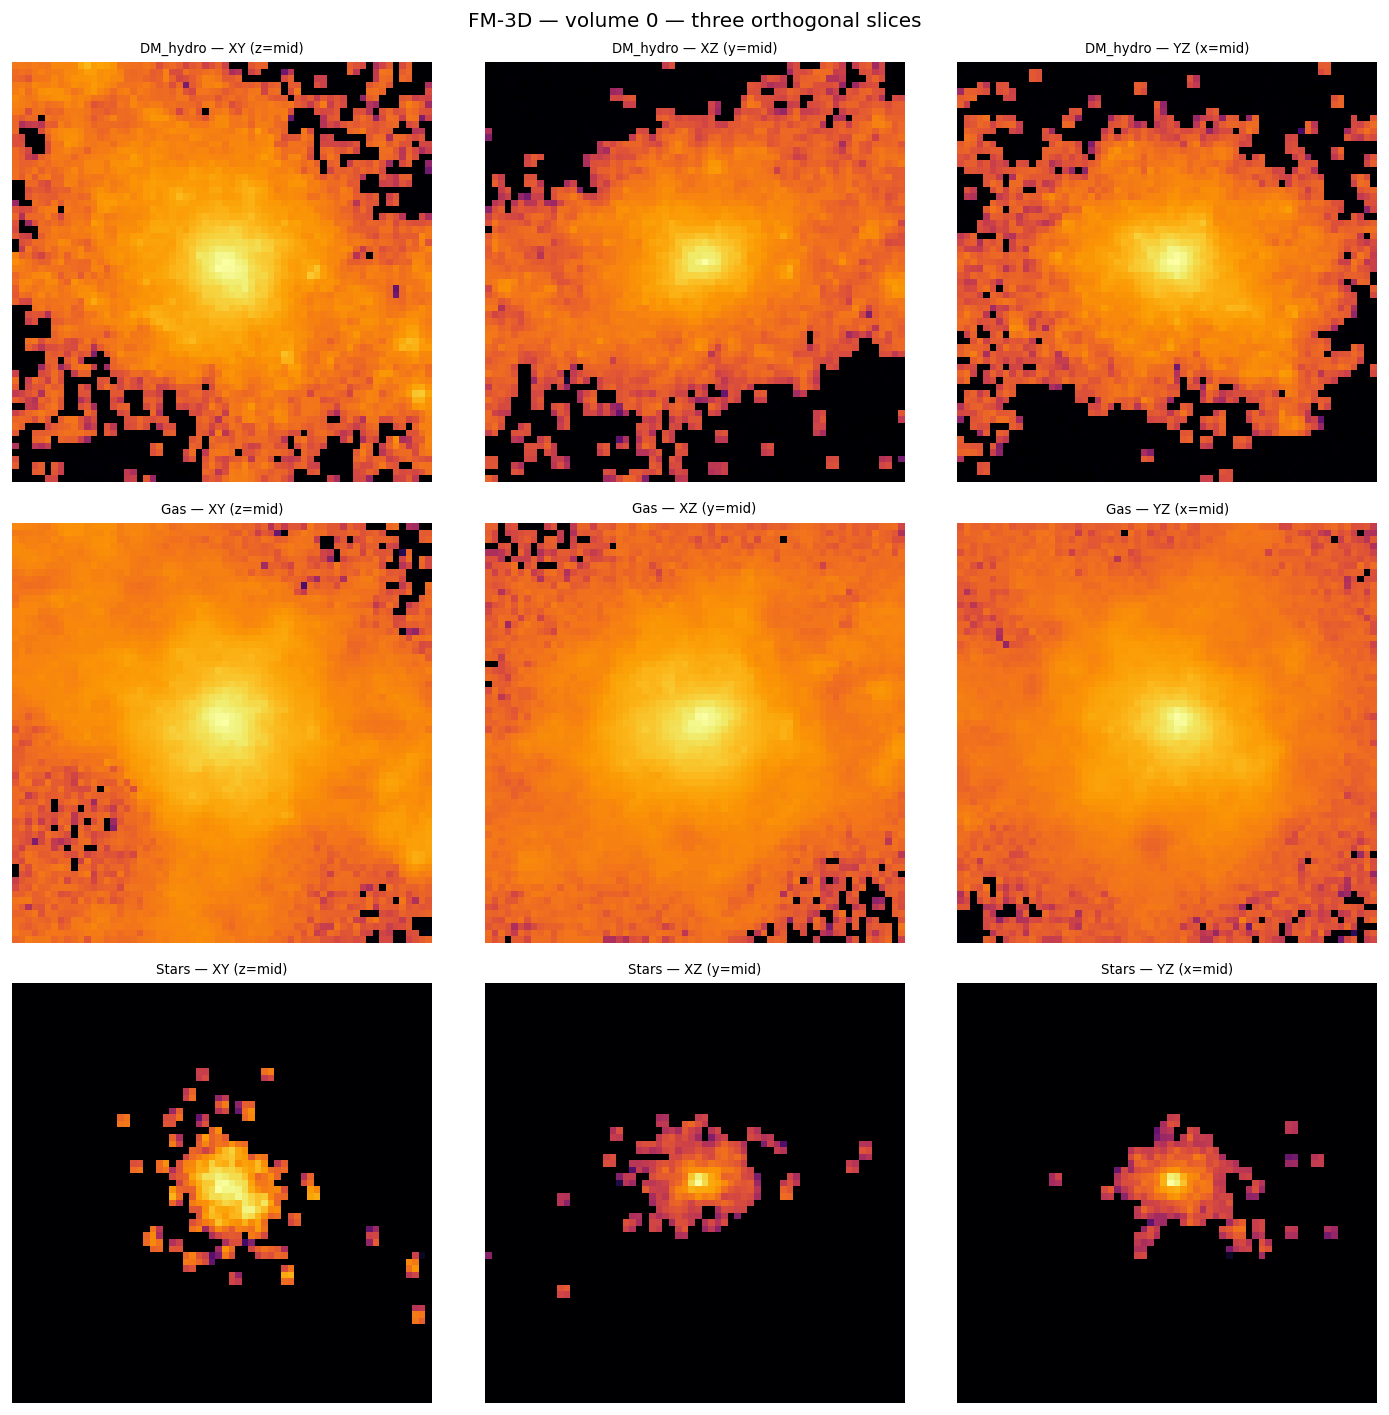

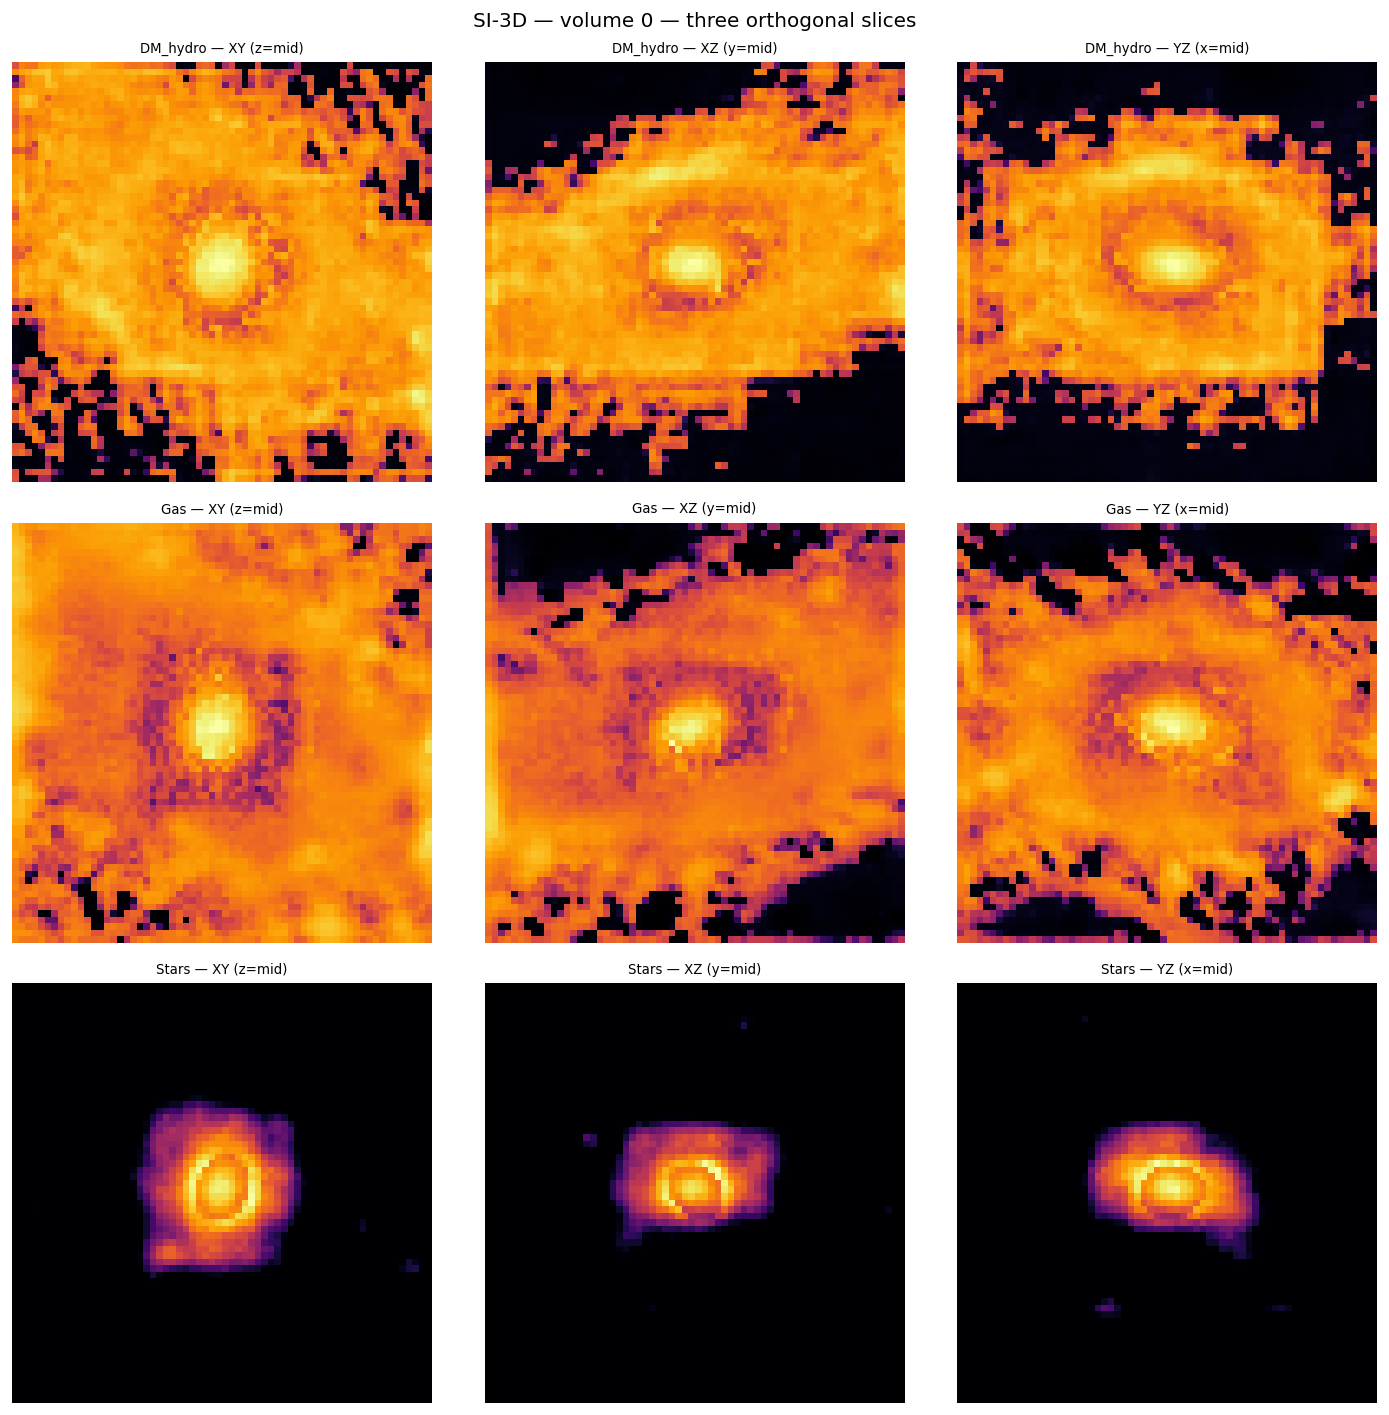

In [7]:
# Three orthogonal slices for one example volume
IDX = 0
for lbl in ['True'] + run_labels:
    vol = real[IDX] if lbl == 'True' else results[lbl]['gen'][IDX]
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for ch in range(3):
        mid = CROP_SIZE // 2
        for pi, (slc, plane) in enumerate([
            (vol[ch, mid, :, :], 'XY (z=mid)'),
            (vol[ch, :, mid, :], 'XZ (y=mid)'),
            (vol[ch, :, :, mid], 'YZ (x=mid)'),
        ]):
            ax = axes[ch, pi]
            ax.imshow(np.log10(slc + 1), cmap='inferno', origin='lower')
            ax.set_title(f'{CHANNEL_NAMES[ch]} — {plane}', fontsize=8)
            ax.axis('off')
    plt.suptitle(f'{lbl} — volume {IDX} — three orthogonal slices', fontsize=12)
    plt.tight_layout()
    plt.show()

## 2. Mass Matching
Total voxel sum per volume: emulated vs truth.

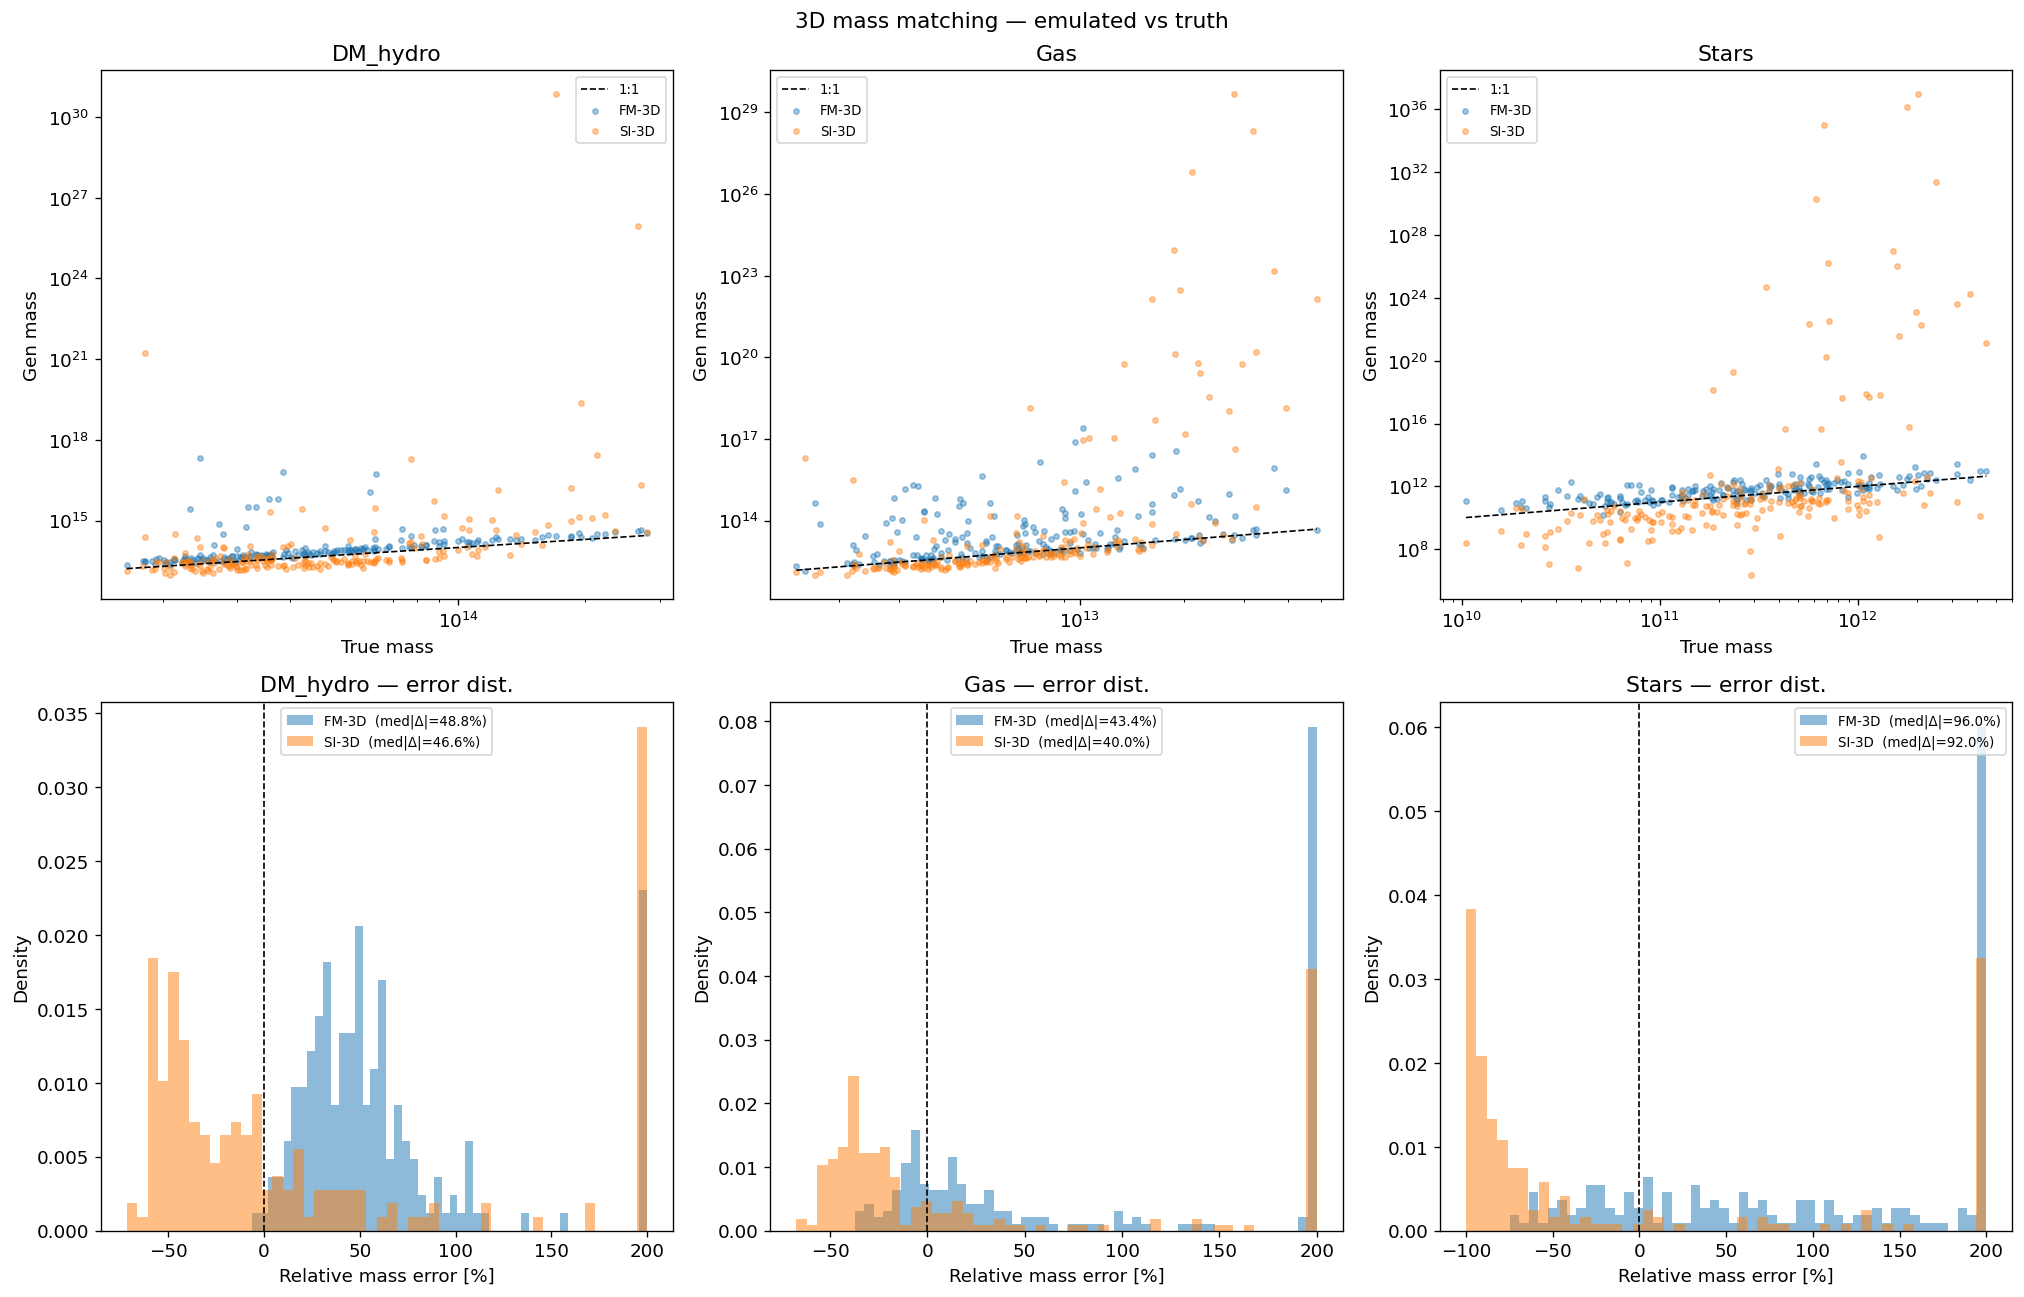


─── Median |relative mass error| per channel [%] ───
Channel            FM-3D       SI-3D
DM_hydro           48.83       46.55
Gas                43.39       39.95
Stars              96.02       92.04


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))

for ch in range(3):
    m_true = real[:, ch].sum(axis=(-3, -2, -1))   # sum over D,H,W

    ax = axes[0, ch]
    ax.plot([m_true.min(), m_true.max()], [m_true.min(), m_true.max()],
            'k--', lw=1, label='1:1')
    for lbl, res in results.items():
        m_gen = res['gen'][:, ch].sum(axis=(-3, -2, -1))
        ax.scatter(m_true, m_gen, s=10, alpha=0.4, color=RUN_COLORS[lbl], label=lbl)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('True mass'); ax.set_ylabel('Gen mass')
    ax.set_title(CHANNEL_NAMES[ch]); ax.legend(fontsize=8)

    ax2 = axes[1, ch]
    for lbl, res in results.items():
        m_gen = res['gen'][:, ch].sum(axis=(-3, -2, -1))
        rel_err = (m_gen - m_true) / (m_true + 1e-30) * 100
        med = np.median(np.abs(rel_err))
        ax2.hist(np.clip(rel_err, -200, 200), bins=50, density=True,
                 alpha=0.5, color=RUN_COLORS[lbl],
                 label=f'{lbl}  (med|Δ|={med:.1f}%)')
    ax2.axvline(0, color='k', lw=1, ls='--')
    ax2.set_xlabel('Relative mass error [%]')
    ax2.set_ylabel('Density')
    ax2.set_title(f'{CHANNEL_NAMES[ch]} — error dist.')
    ax2.legend(fontsize=8)

plt.suptitle('3D mass matching — emulated vs truth', fontsize=13)
plt.tight_layout()
plt.show()

print('\n─── Median |relative mass error| per channel [%] ───')
hdr = f'{"Channel":<12}' + ''.join(f'{lbl:>12}' for lbl in results)
print(hdr)
for ch, name in enumerate(CHANNEL_NAMES):
    m_true = real[:, ch].sum(axis=(-3, -2, -1))
    row = f'{name:<12}'
    for lbl, res in results.items():
        m_gen = res['gen'][:, ch].sum(axis=(-3, -2, -1))
        err = np.median(np.abs((m_gen - m_true) / (m_true + 1e-30))) * 100
        row += f'{err:>12.2f}'
    print(row)

## 3. 3D Power Spectra
### 3a. Individual volume P(k) — batch mean ± std  
### 3b. Mean-field P(k) — catalog-level systematic check

Computing 3D power spectra (this takes a moment)...


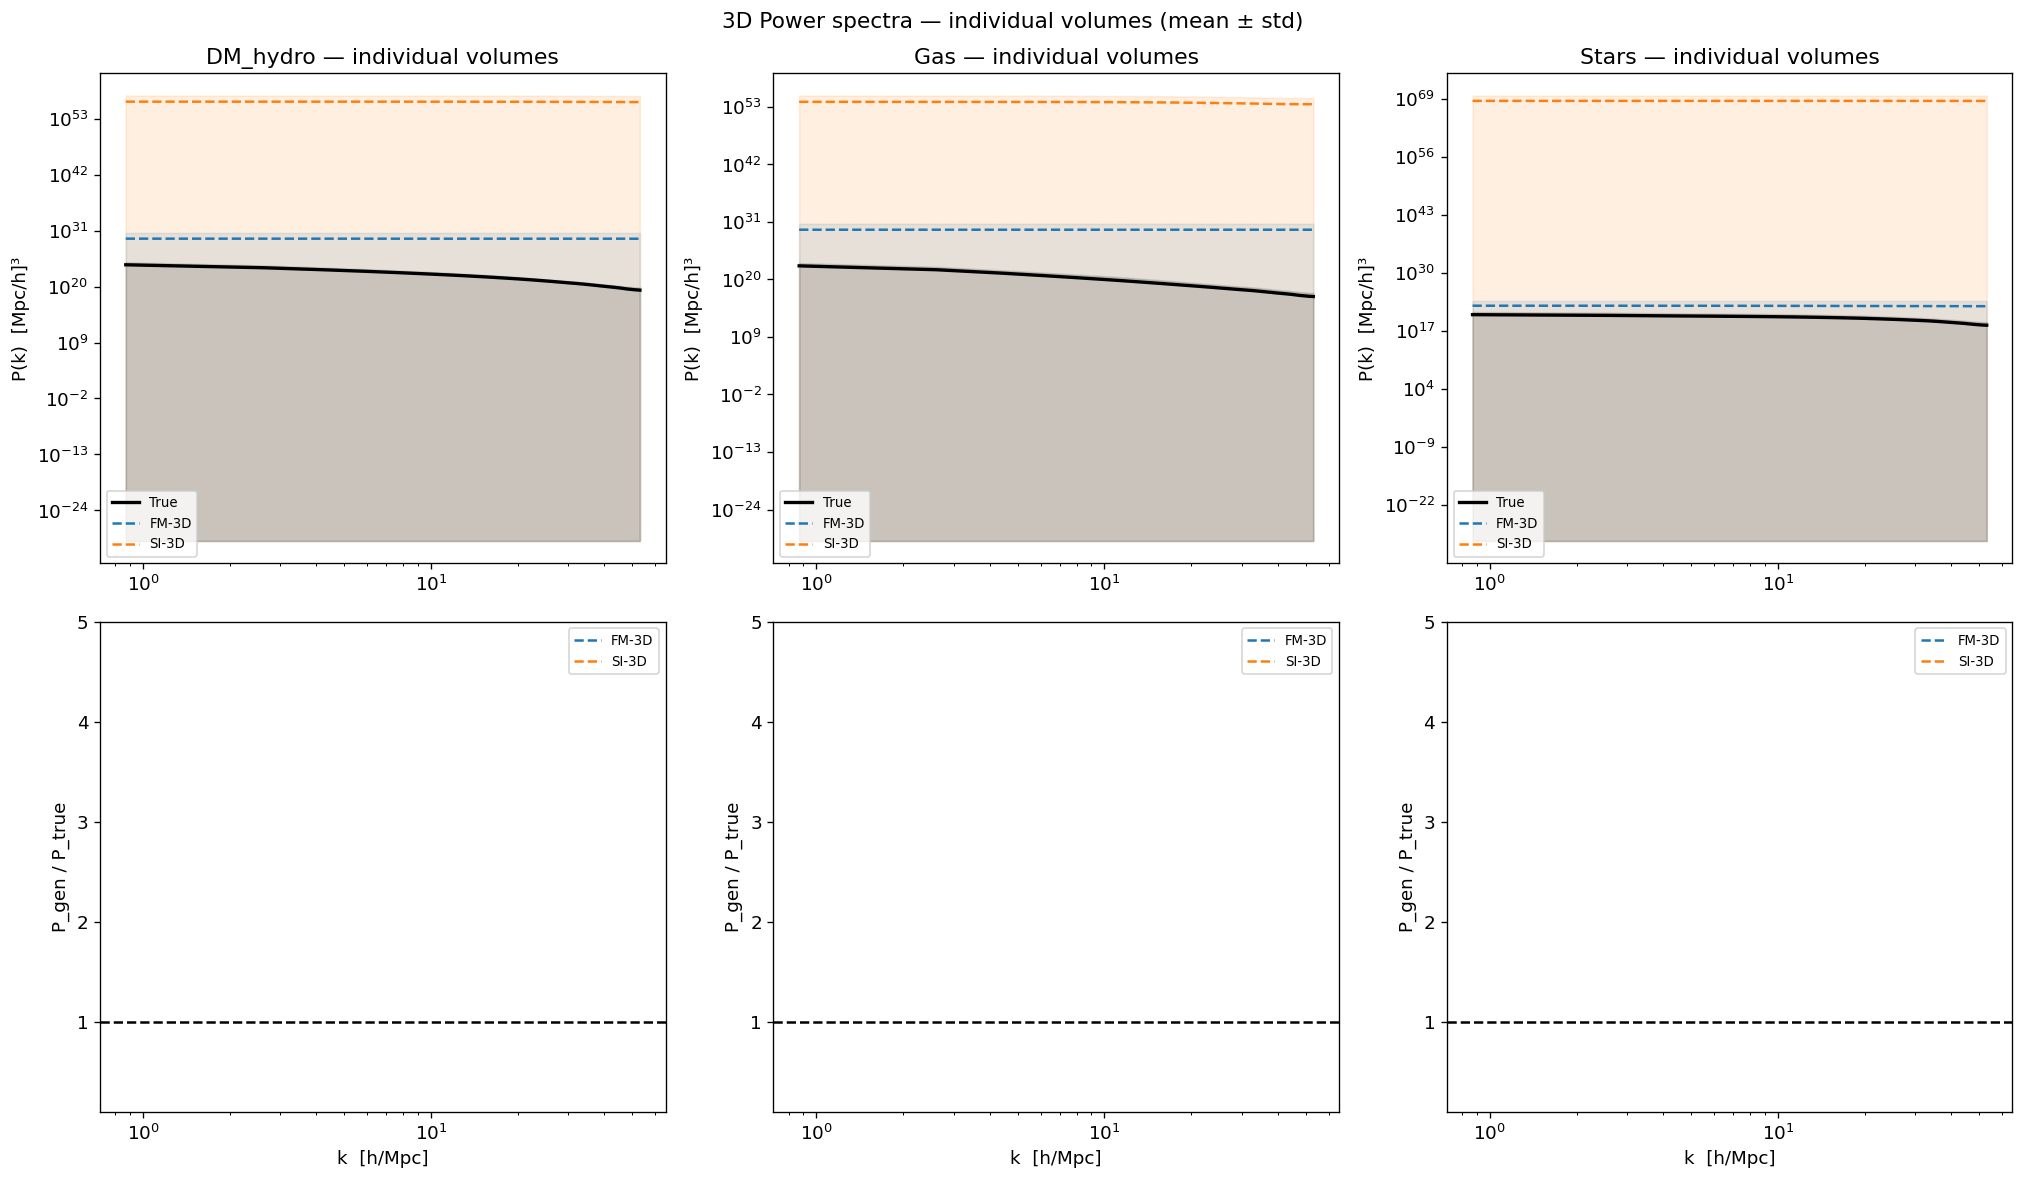

In [9]:
print('Computing 3D power spectra (this takes a moment)...')

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ch in range(3):
    k, pk_r, pk_r_std = batch_power_spectra_3d(real[:, ch], BOX_SIZE)
    ax_top = axes[0, ch]
    ax_bot = axes[1, ch]

    ax_top.loglog(k[k > 0], pk_r[k > 0], 'k-', lw=2, label='True')
    ax_top.fill_between(k[k > 0],
                        np.maximum(pk_r - pk_r_std, 1e-30)[k > 0],
                        (pk_r + pk_r_std)[k > 0],
                        alpha=0.15, color='k')
    ax_bot.axhline(1, color='k', lw=1.5, ls='--')

    for lbl, res in results.items():
        c = RUN_COLORS[lbl]
        _, pk_g, pk_g_std = batch_power_spectra_3d(res['gen'][:, ch], BOX_SIZE)
        ax_top.loglog(k[k > 0], pk_g[k > 0], '--', color=c, lw=1.5, label=lbl)
        ax_top.fill_between(k[k > 0],
                            np.maximum(pk_g - pk_g_std, 1e-30)[k > 0],
                            (pk_g + pk_g_std)[k > 0],
                            alpha=0.12, color=c)
        ratio = pk_g / (pk_r + 1e-30)
        ax_bot.semilogx(k[k > 0], ratio[k > 0], '--', color=c, lw=1.5, label=lbl)

    ax_top.set_ylabel('P(k)  [Mpc/h]³')
    ax_top.set_title(f'{CHANNEL_NAMES[ch]} — individual volumes')
    ax_top.legend(fontsize=8)
    ax_bot.set_xlabel('k  [h/Mpc]')
    ax_bot.set_ylabel('P_gen / P_true')
    ax_bot.set_ylim(0.1, 5.0)
    ax_bot.legend(fontsize=8)

plt.suptitle('3D Power spectra — individual volumes (mean ± std)', fontsize=13)
plt.tight_layout()
plt.show()

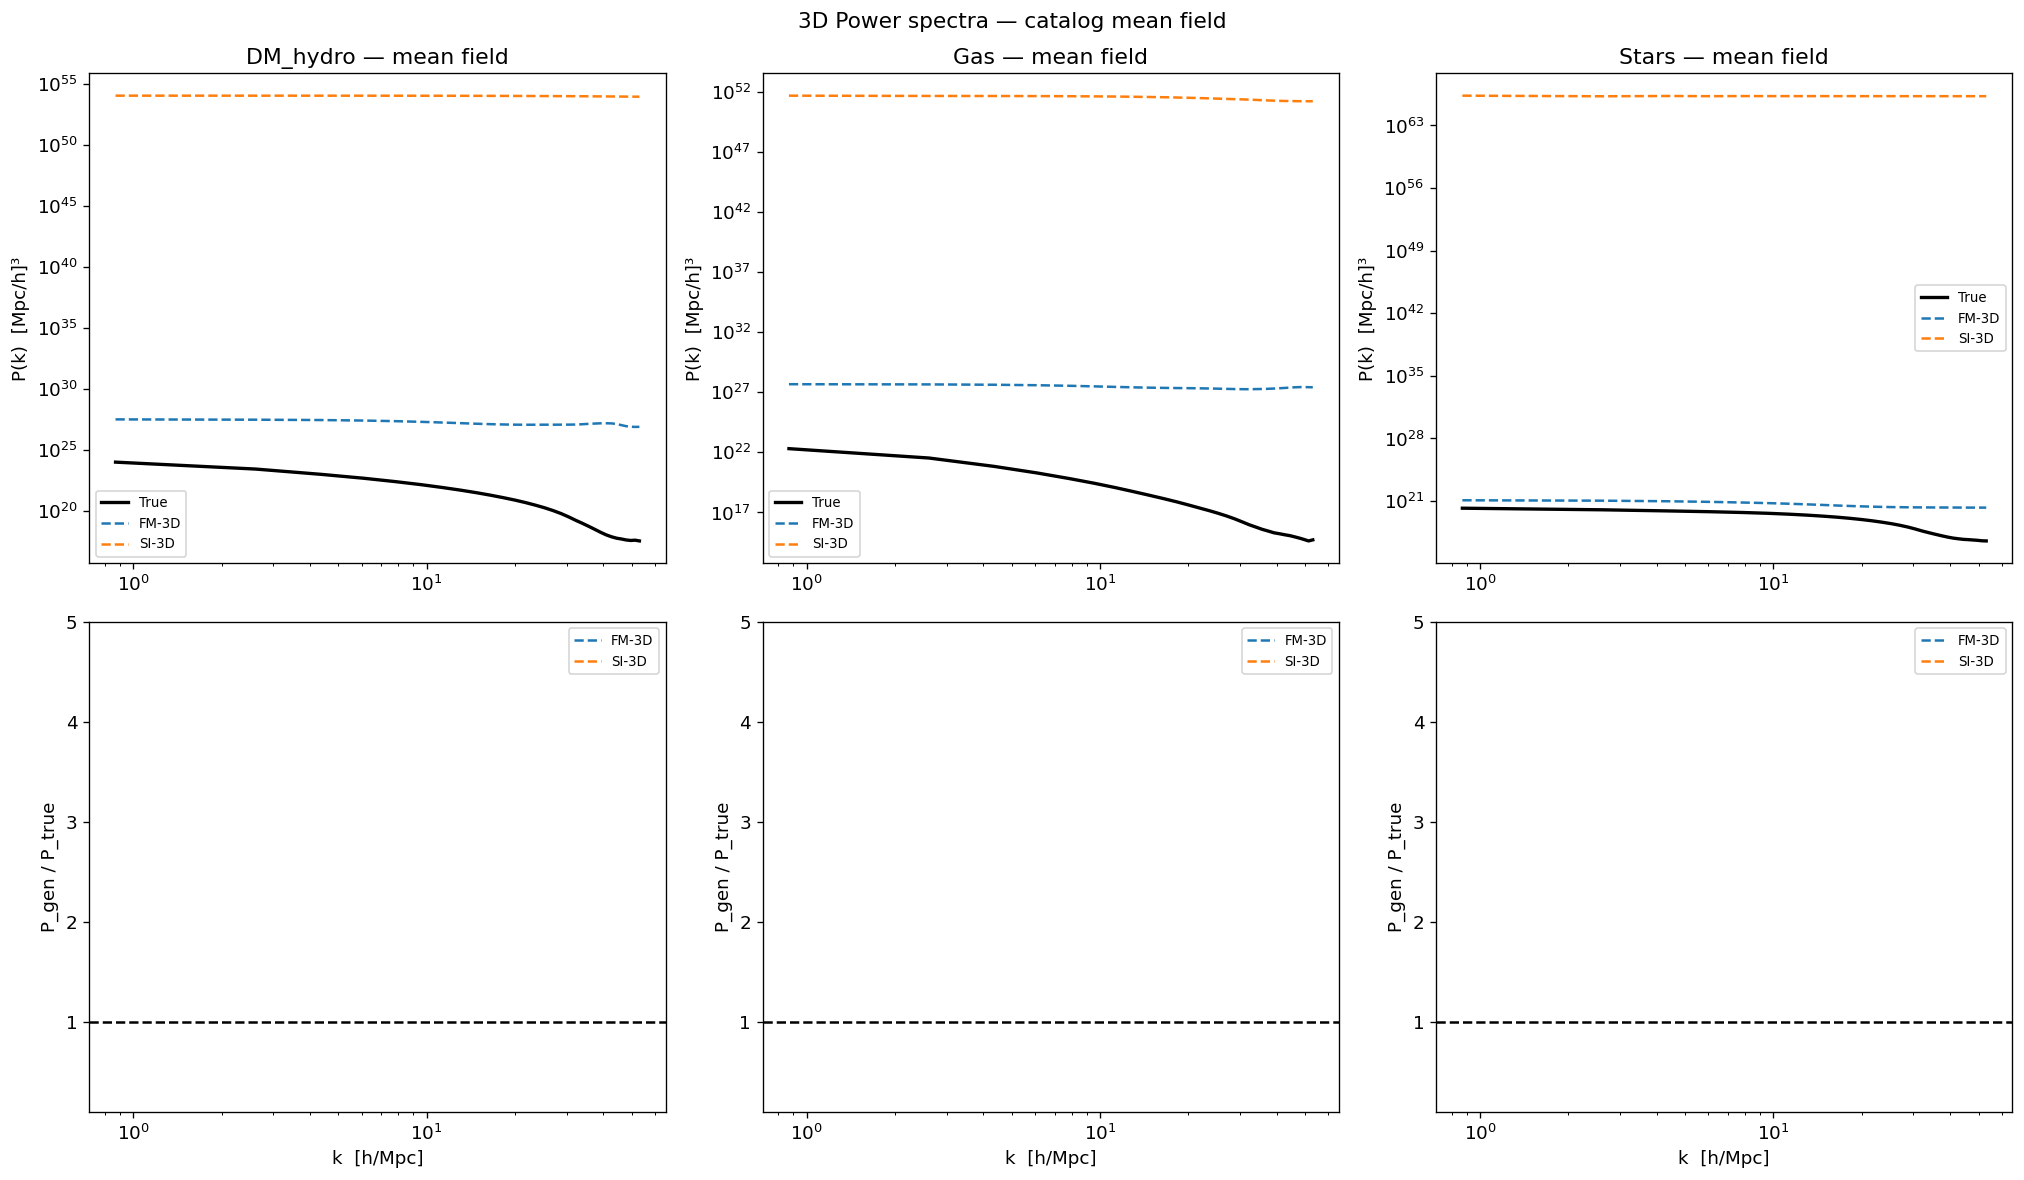


─── Mean-field P(k): median |log10(gen/true)| ───
Channel            FM-3D       SI-3D
DM_hydro          7.0366     33.9540
Gas              10.5696     34.6876
Stars             2.0236     47.9541


In [24]:
# Catalog-level: P(k) of mean field over test set
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ch in range(3):
    mean_true = real[:, ch].mean(axis=0)  # (64, 64, 64)
    k, pk_r = power_spectrum_3d(mean_true, BOX_SIZE)

    ax_top = axes[0, ch]
    ax_bot = axes[1, ch]
    mask = k > 0

    ax_top.loglog(k[mask], pk_r[mask], 'k-', lw=2, label='True')
    ax_bot.axhline(1, color='k', lw=1.5, ls='--')

    for lbl, res in results.items():
        c = RUN_COLORS[lbl]
        mean_gen = res['gen'][:, ch].mean(axis=0)
        _, pk_g = power_spectrum_3d(mean_gen, BOX_SIZE)
        ax_top.loglog(k[mask], pk_g[mask], '--', color=c, lw=1.5, label=lbl)
        ratio = pk_g / (pk_r + 1e-30)
        ax_bot.semilogx(k[mask], ratio[mask], '--', color=c, lw=1.5, label=lbl)

    ax_top.set_ylabel('P(k)  [Mpc/h]³')
    ax_top.set_title(f'{CHANNEL_NAMES[ch]} — mean field')
    ax_top.legend(fontsize=8)
    ax_bot.set_xlabel('k  [h/Mpc]')
    ax_bot.set_ylabel('P_gen / P_true')
    ax_bot.set_ylim(0.1, 5.0)
    ax_bot.legend(fontsize=8)

plt.suptitle('3D Power spectra — catalog mean field', fontsize=13)
plt.tight_layout()
plt.show()

print('\n─── Mean-field P(k): median |log10(gen/true)| ───')
hdr = f'{"Channel":<12}' + ''.join(f'{lbl:>12}' for lbl in results)
print(hdr)
for ch, name in enumerate(CHANNEL_NAMES):
    mean_true = real[:, ch].mean(axis=0)
    k, pk_r = power_spectrum_3d(mean_true, BOX_SIZE)
    mask = (k > 0) & (pk_r > 0)
    row = f'{name:<12}'
    for lbl, res in results.items():
        mean_gen = res['gen'][:, ch].mean(axis=0)
        _, pk_g = power_spectrum_3d(mean_gen, BOX_SIZE)
        err = np.median(np.abs(np.log10(pk_g[mask] / pk_r[mask] + 1e-10)))
        row += f'{err:>12.4f}'
    print(row)

## 4. 3D Radial Profiles
Mean voxel value as a function of 3D distance from the volume centre.  
r_max = 32 voxels = 3.125 Mpc/h (to box edge).

Computing 3D radial profiles...


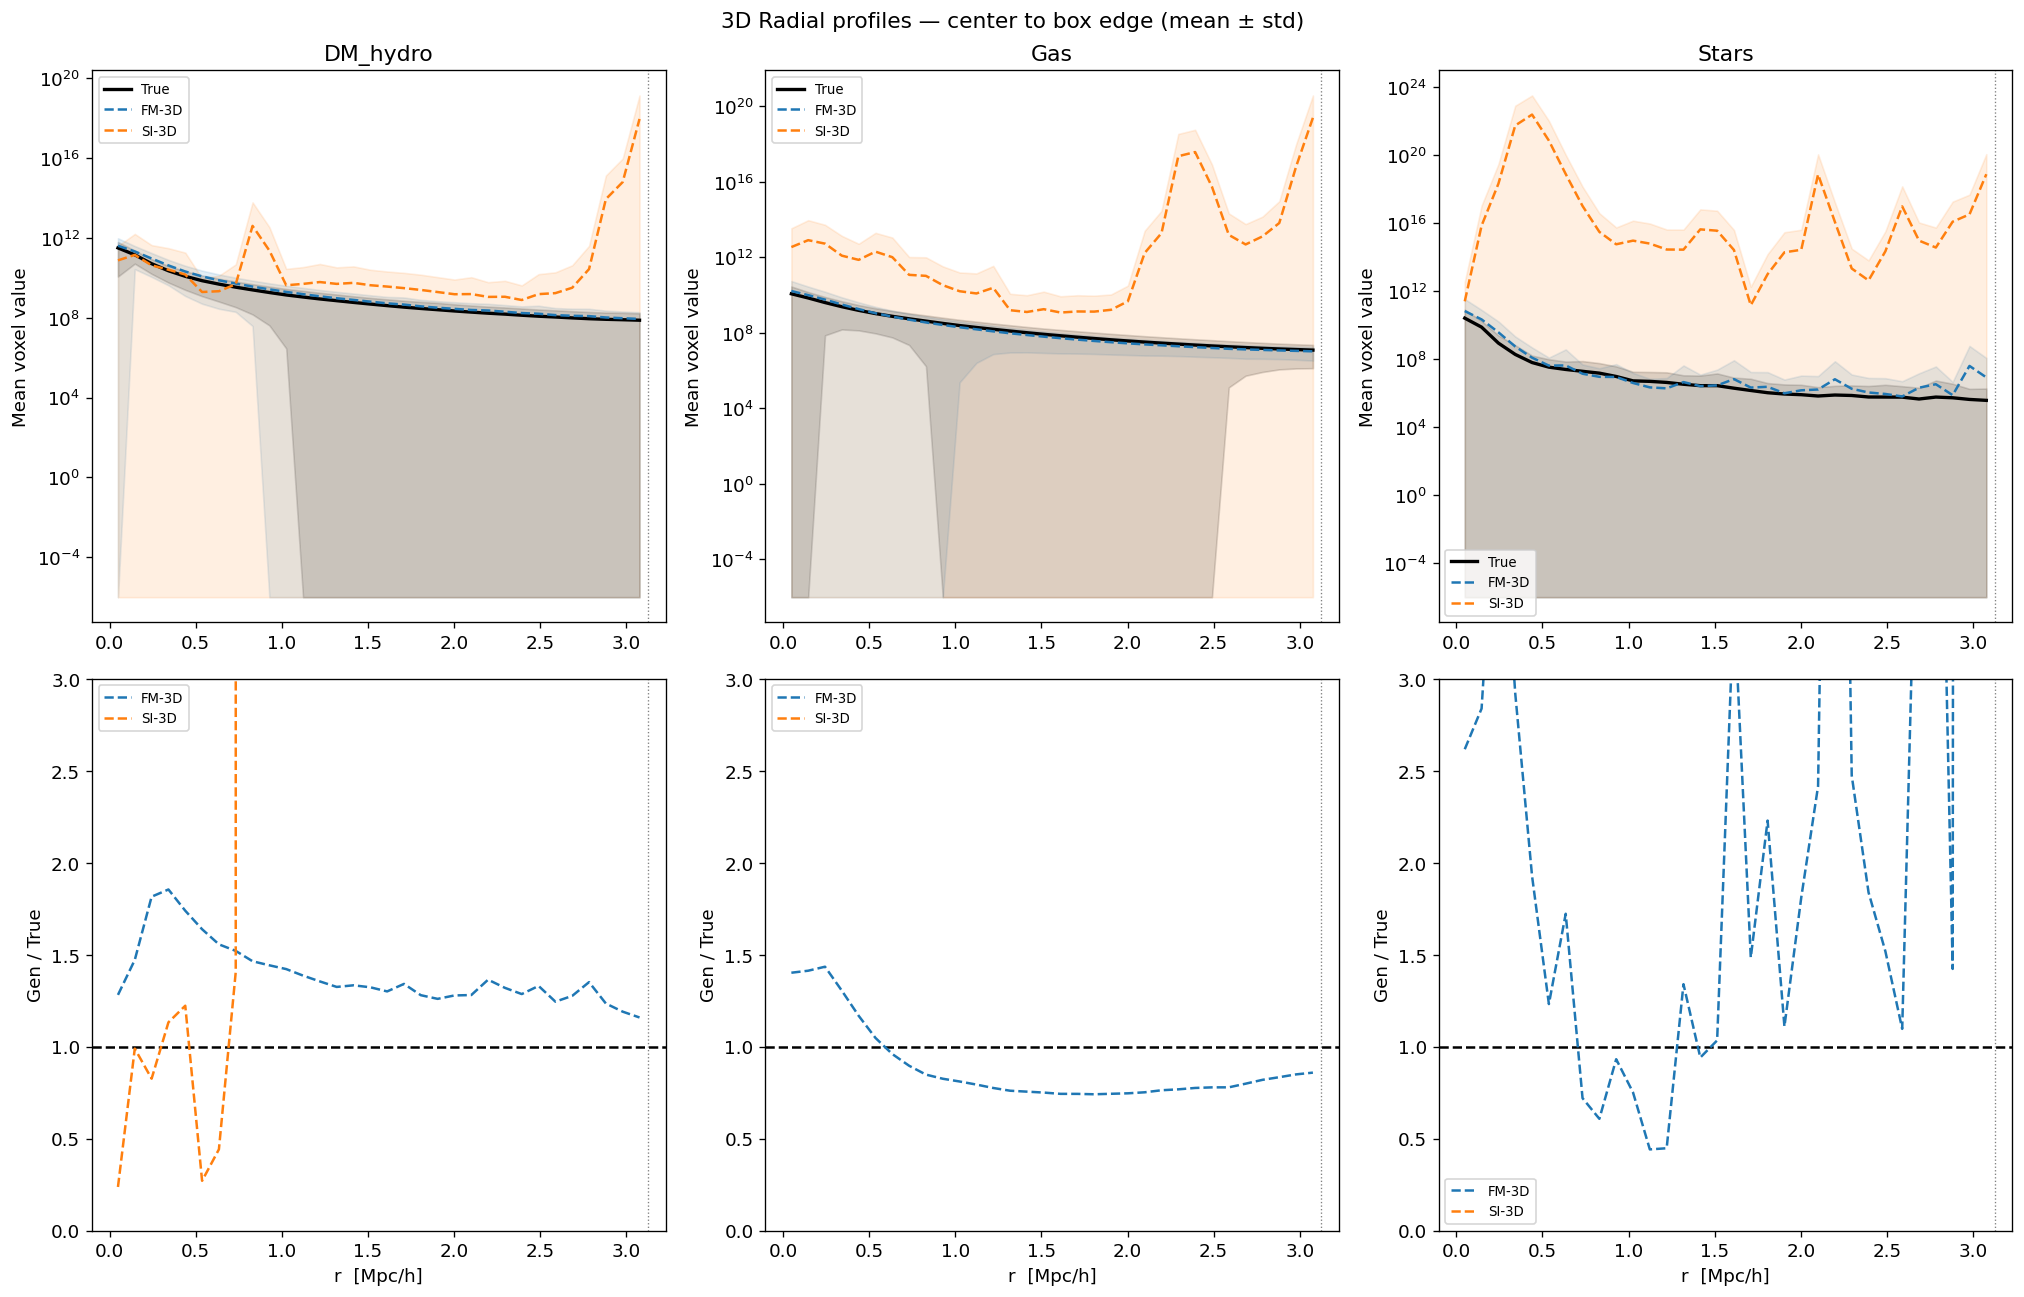

In [21]:
N_BINS = 32
print('Computing 3D radial profiles...')

fig, axes = plt.subplots(2, 3, figsize=(17, 11))

for ch in range(3):
    r_pix, pr_mean, pr_std = batch_profiles_3d(real[:, ch], n_bins=N_BINS)
    r_mpc = r_pix * PIX_SIZE

    ax_top = axes[0, ch]
    ax_bot = axes[1, ch]

    ax_top.semilogy(r_mpc, pr_mean + 1e-6, 'k-', lw=2, label='True')
    ax_top.fill_between(r_mpc,
                        np.maximum(pr_mean - pr_std, 1e-6),
                        pr_mean + pr_std + 1e-6,
                        alpha=0.15, color='k')
    ax_bot.axhline(1, color='k', lw=1.5, ls='--')

    for lbl, res in results.items():
        c = RUN_COLORS[lbl]
        _, pg_mean, pg_std = batch_profiles_3d(res['gen'][:, ch], n_bins=N_BINS)
        ax_top.semilogy(r_mpc, pg_mean + 1e-6, '--', color=c, lw=1.5, label=lbl)
        ax_top.fill_between(r_mpc,
                            np.maximum(pg_mean - pg_std, 1e-6),
                            pg_mean + pg_std + 1e-6,
                            alpha=0.12, color=c)
        ratio = (pg_mean + 1e-8) / (pr_mean + 1e-8)
        ax_bot.plot(r_mpc, ratio, '--', color=c, lw=1.5, label=lbl)

    ax_top.set_ylabel('Mean voxel value')
    ax_top.set_title(CHANNEL_NAMES[ch])
    ax_top.legend(fontsize=8)
    ax_bot.set_xlabel('r  [Mpc/h]')
    ax_bot.set_ylabel('Gen / True')
    ax_bot.set_ylim(0.0, 3.0)
    ax_bot.legend(fontsize=8)
    for ax in (ax_top, ax_bot):
        ax.axvline(BOX_SIZE / 2, color='gray', lw=0.8, ls=':', label='box edge')

plt.suptitle('3D Radial profiles — center to box edge (mean ± std)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. In-Distribution Check
### 5a. Voxel value distributions + KS test
### 5b. 2D joint distributions (scaling relations)
### 5c. Volume total mass function
### 5d. Stellar occupancy

─── Two-sample KS test: generated vs truth ───
  DM_hydro     FM-3D: KS=0.3136, p=0.000e+00
  DM_hydro     SI-3D: KS=0.3801, p=0.000e+00
  Gas          FM-3D: KS=0.1707, p=0.000e+00
  Gas          SI-3D: KS=0.1607, p=0.000e+00
  Stars        FM-3D: KS=0.6273, p=0.000e+00
  Stars        SI-3D: KS=0.7984, p=0.000e+00


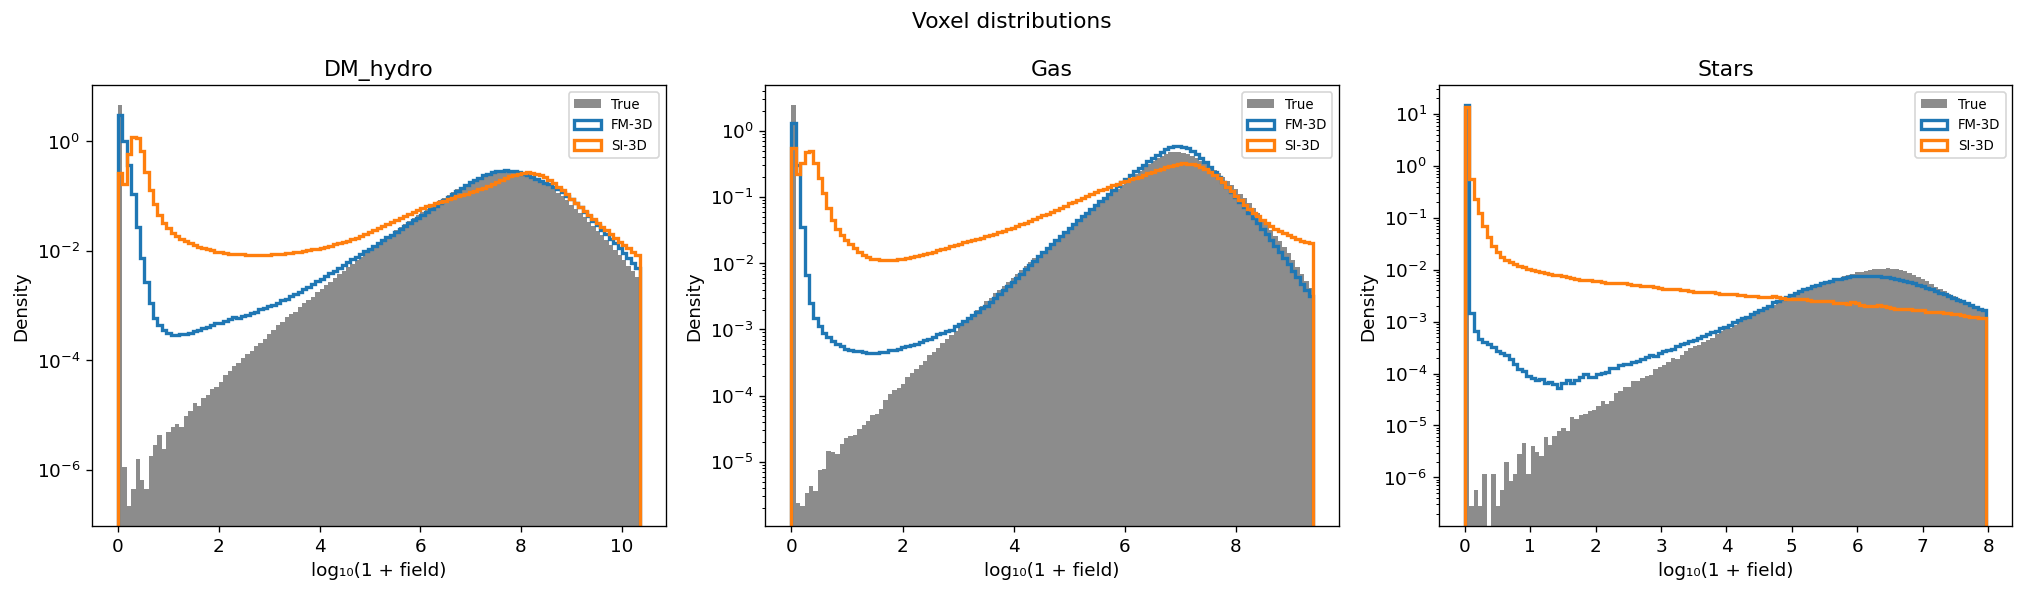

In [22]:
# 5a. Voxel distributions
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
print('─── Two-sample KS test: generated vs truth ───')

for ch in range(3):
    r_flat = np.log10(real[:, ch].flatten() + 1)
    p99 = np.percentile(r_flat, 99.9)
    bins = np.linspace(0, p99, 120)
    ax = axes[ch]
    ax.hist(r_flat, bins=bins, density=True, alpha=0.45, color='k', label='True')
    for lbl, res in results.items():
        g_flat = np.log10(res['gen'][:, ch].flatten() + 1)
        ax.hist(g_flat, bins=bins, density=True, histtype='step',
                lw=2, color=RUN_COLORS[lbl], label=lbl)
        ks_stat, ks_p = stats.ks_2samp(r_flat[::50], g_flat[::50])
        print(f'  {CHANNEL_NAMES[ch]:12s} {lbl}: KS={ks_stat:.4f}, p={ks_p:.3e}')
    ax.set_xlabel('log₁₀(1 + field)')
    ax.set_ylabel('Density')
    ax.set_yscale('log')
    ax.set_title(CHANNEL_NAMES[ch])
    ax.legend(fontsize=8)

plt.suptitle('Voxel distributions', fontsize=13)
plt.tight_layout()
plt.show()

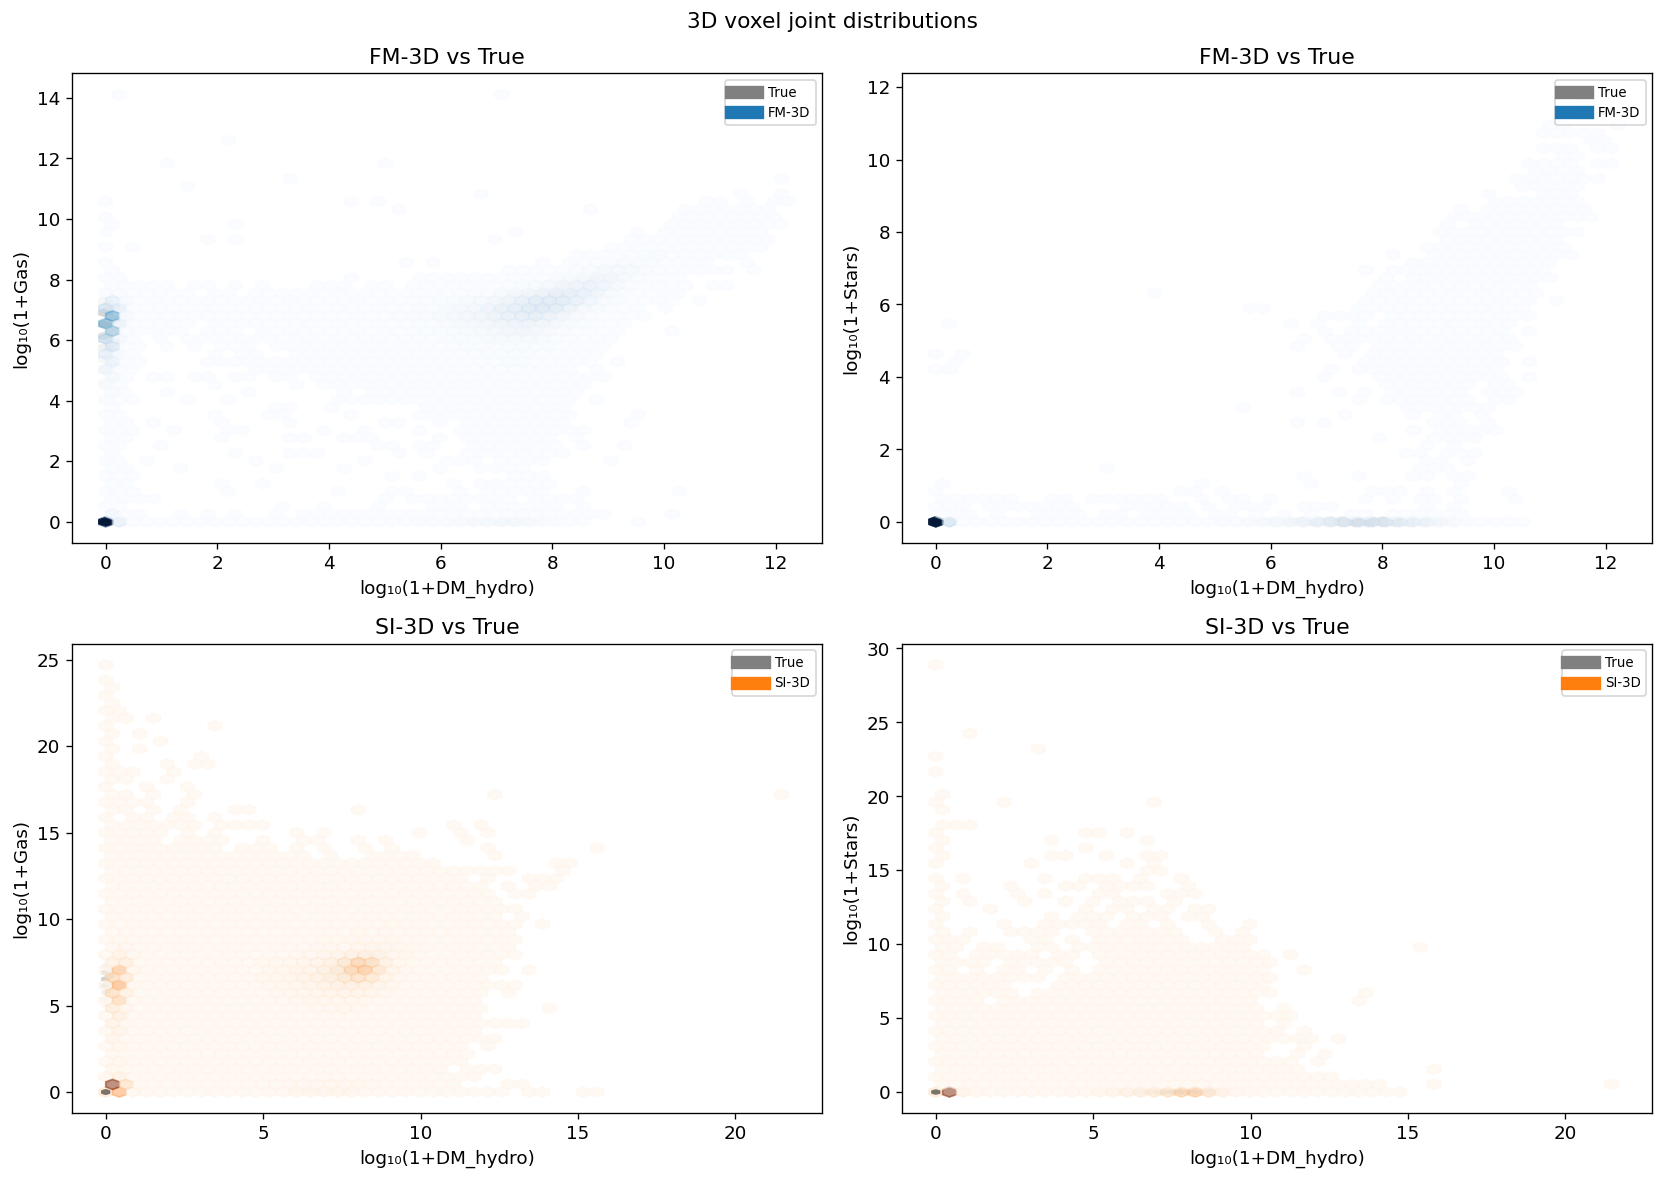

In [13]:
# 5b. 2D joint distributions: Gas vs DM, Stars vs DM
subsample = 200  # every N-th voxel — 3D arrays are large

fig, axes = plt.subplots(len(results), 2, figsize=(14, 5 * len(results)))
if len(results) == 1:
    axes = axes[np.newaxis, :]

log_dm_true   = np.log10(real[:, 0].flatten()[::subsample] + 1)
log_gas_true  = np.log10(real[:, 1].flatten()[::subsample] + 1)
log_star_true = np.log10(real[:, 2].flatten()[::subsample] + 1)

for ri, (lbl, res) in enumerate(results.items()):
    log_dm_g   = np.log10(res['gen'][:, 0].flatten()[::subsample] + 1)
    log_gas_g  = np.log10(res['gen'][:, 1].flatten()[::subsample] + 1)
    log_star_g = np.log10(res['gen'][:, 2].flatten()[::subsample] + 1)

    for col, (x_t, y_t, x_g, y_g, ylabel) in enumerate([
        (log_dm_true, log_gas_true,  log_dm_g, log_gas_g,  'log₁₀(1+Gas)'),
        (log_dm_true, log_star_true, log_dm_g, log_star_g, 'log₁₀(1+Stars)'),
    ]):
        ax = axes[ri, col]
        ax.hexbin(x_t, y_t, gridsize=50, cmap='Greys', mincnt=1)
        ax.hexbin(x_g, y_g, gridsize=50,
                  cmap=plt.cm.Blues if 'FM' in lbl else plt.cm.Oranges,
                  mincnt=1, alpha=0.5)
        ax.set_xlabel('log₁₀(1+DM_hydro)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{lbl} vs True')
        ax.legend(handles=[
            plt.Line2D([0],[0], color='gray', lw=8, label='True'),
            plt.Line2D([0],[0], color=RUN_COLORS[lbl], lw=8, label=lbl),
        ], fontsize=8)

plt.suptitle('3D voxel joint distributions', fontsize=13)
plt.tight_layout()
plt.show()

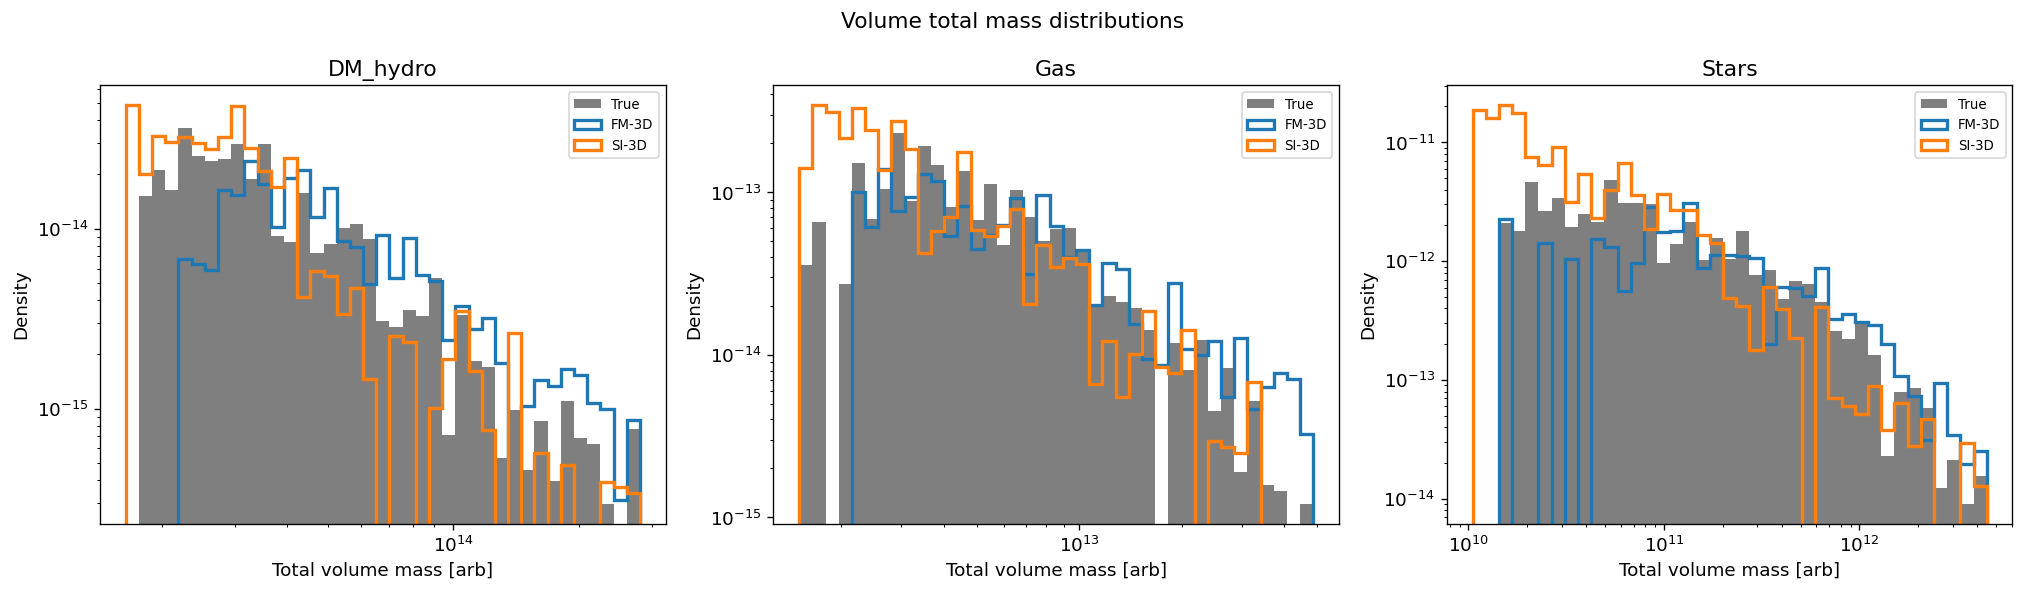


─── Stellar occupancy (fraction of voxels with M* > threshold) ───
  True: 2.16%
  FM-3D: 59.86%  (Δ = +57.70 pp)
  SI-3D: 81.38%  (Δ = +79.22 pp)


In [23]:
# 5c. Volume total mass + 5d. Stellar occupancy
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ch in range(3):
    ax = axes[ch]
    m_true = real[:, ch].sum(axis=(-3, -2, -1))
    pos_mask = m_true > 0
    if pos_mask.any():
        bins = np.logspace(np.log10(m_true[pos_mask].min() + 1),
                           np.log10(m_true.max() + 1), 40)
    else:
        bins = 40
    ax.hist(m_true + 1, bins=bins, density=True, alpha=0.5, color='k', label='True')
    for lbl, res in results.items():
        m_gen = res['gen'][:, ch].sum(axis=(-3, -2, -1))
        ax.hist(m_gen + 1, bins=bins, density=True, histtype='step',
                lw=2, color=RUN_COLORS[lbl], label=lbl)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Total volume mass [arb]')
    ax.set_ylabel('Density')
    ax.set_title(CHANNEL_NAMES[ch])
    ax.legend(fontsize=8)

plt.suptitle('Volume total mass distributions', fontsize=13)
plt.tight_layout()
plt.show()

print('\n─── Stellar occupancy (fraction of voxels with M* > threshold) ───')
true_occ = (real[:, 2] > STAR_THRESH).mean() * 100
print(f'  True: {true_occ:.2f}%')
for lbl, res in results.items():
    gen_occ = (res['gen'][:, 2] > STAR_THRESH).mean() * 100
    print(f'  {lbl}: {gen_occ:.2f}%  (Δ = {gen_occ - true_occ:+.2f} pp)')

## 6. Parameter Sensitivity — Field-Level Differences
Split test volumes into high/low groups along two cosmological parameters.
Good emulators should produce correlated Δ maps with the truth.


Param [0]  lo: 0.370  hi: 0.917  (50 volumes each)


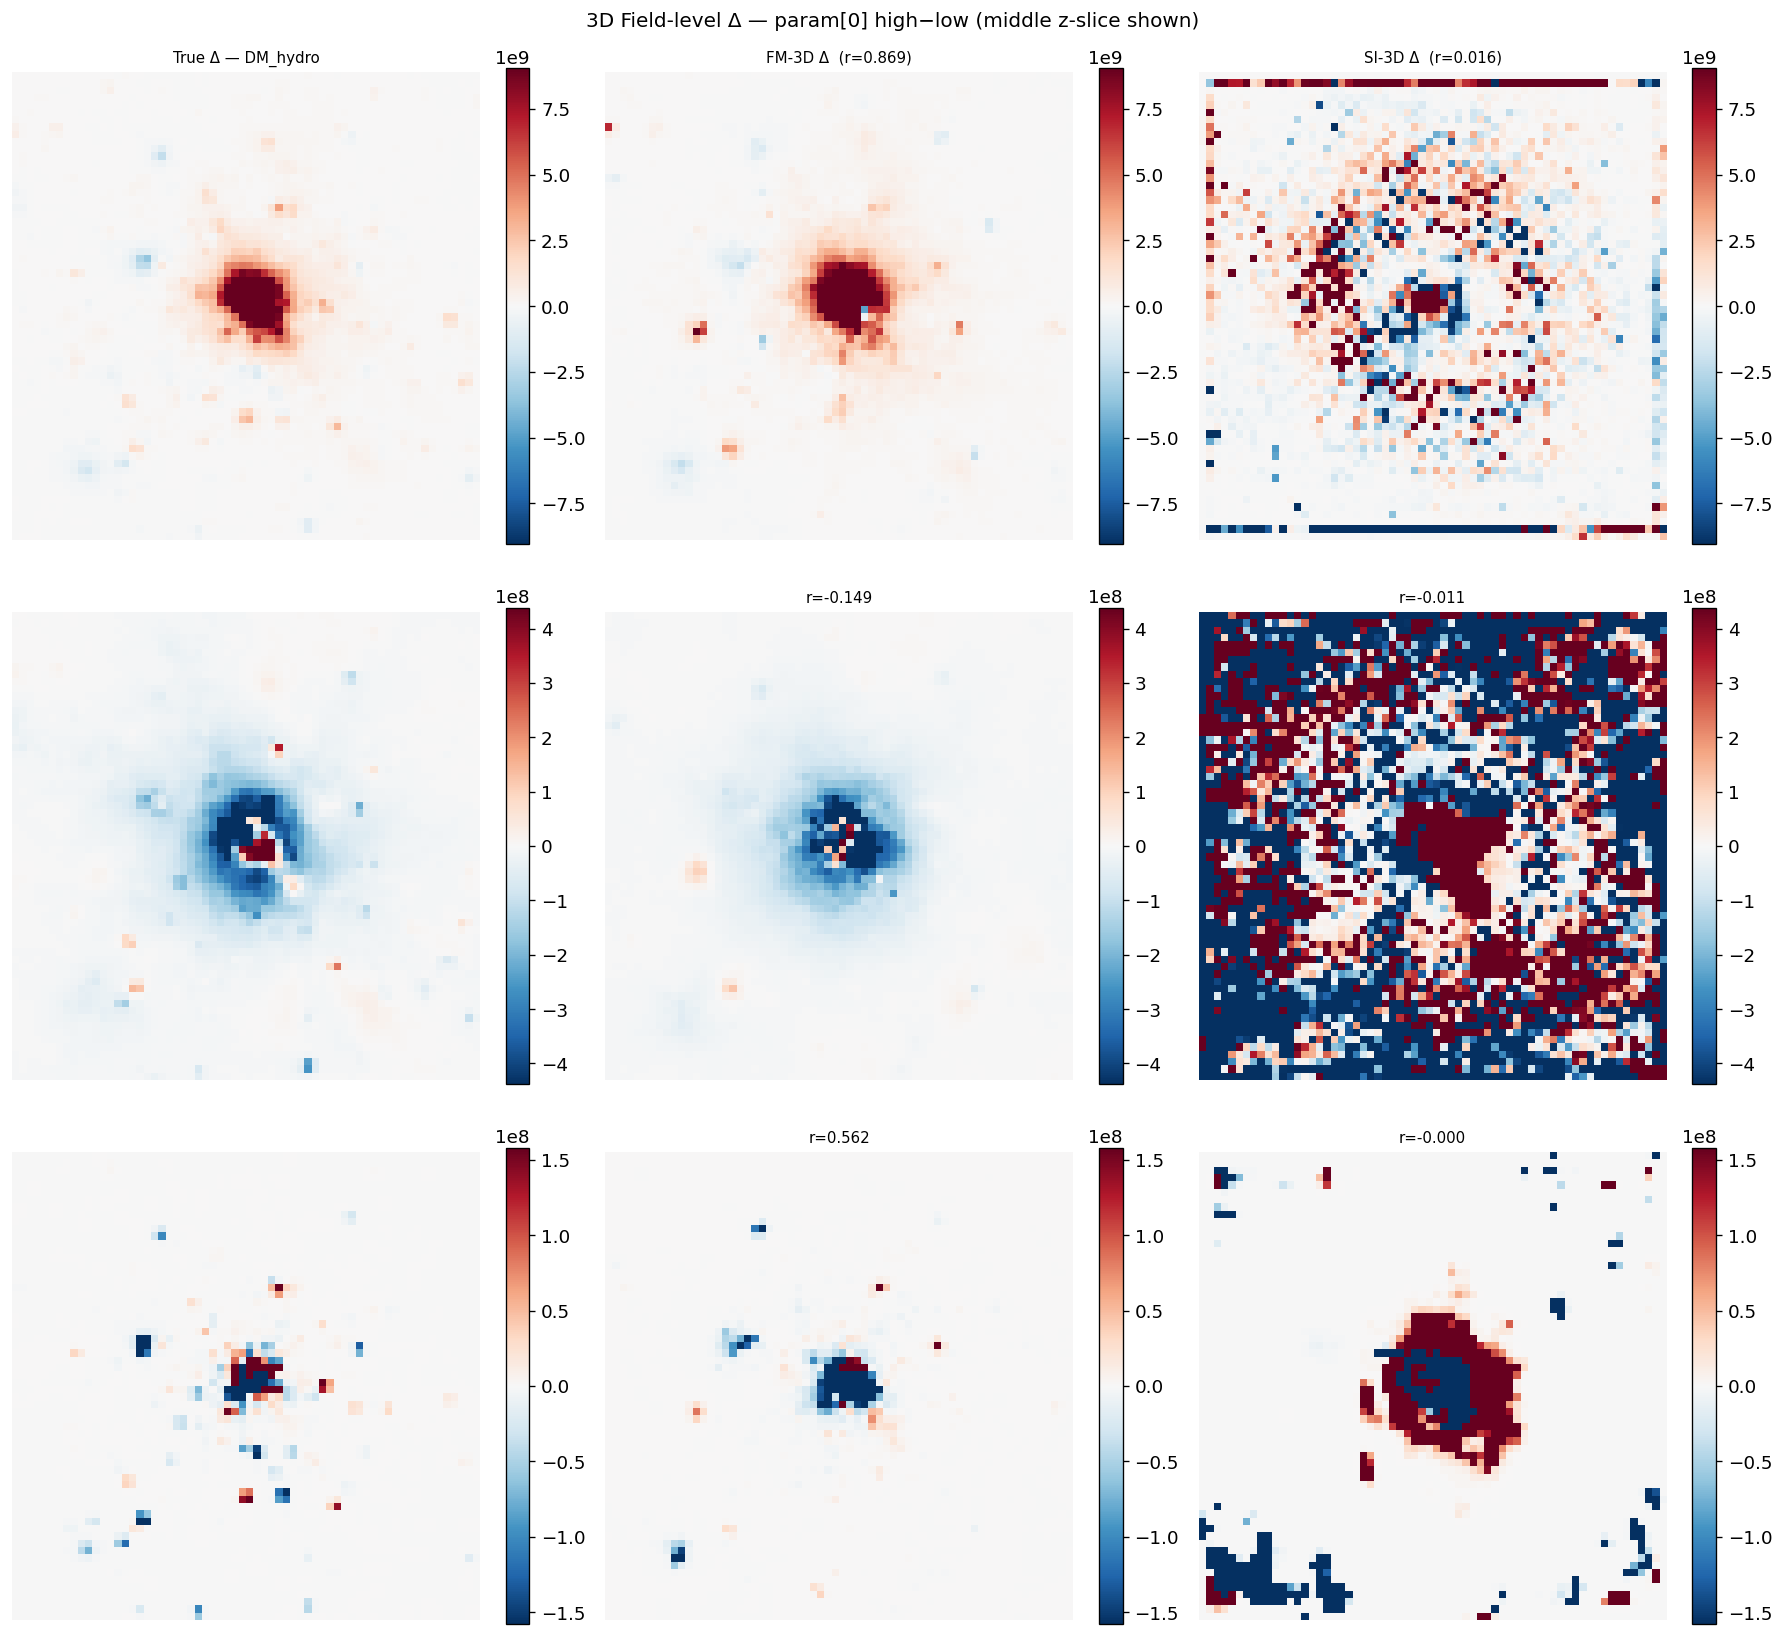

  3D correlation of Δ volumes with truth:
    DM_hydro     FM-3D: r3D = 0.0030
    DM_hydro     SI-3D: r3D = -0.0003
    Gas          FM-3D: r3D = 0.0002
    Gas          SI-3D: r3D = -0.0010
    Stars        FM-3D: r3D = 0.0786
    Stars        SI-3D: r3D = -0.0000

Param [1]  lo: 0.193  hi: 0.935  (50 volumes each)


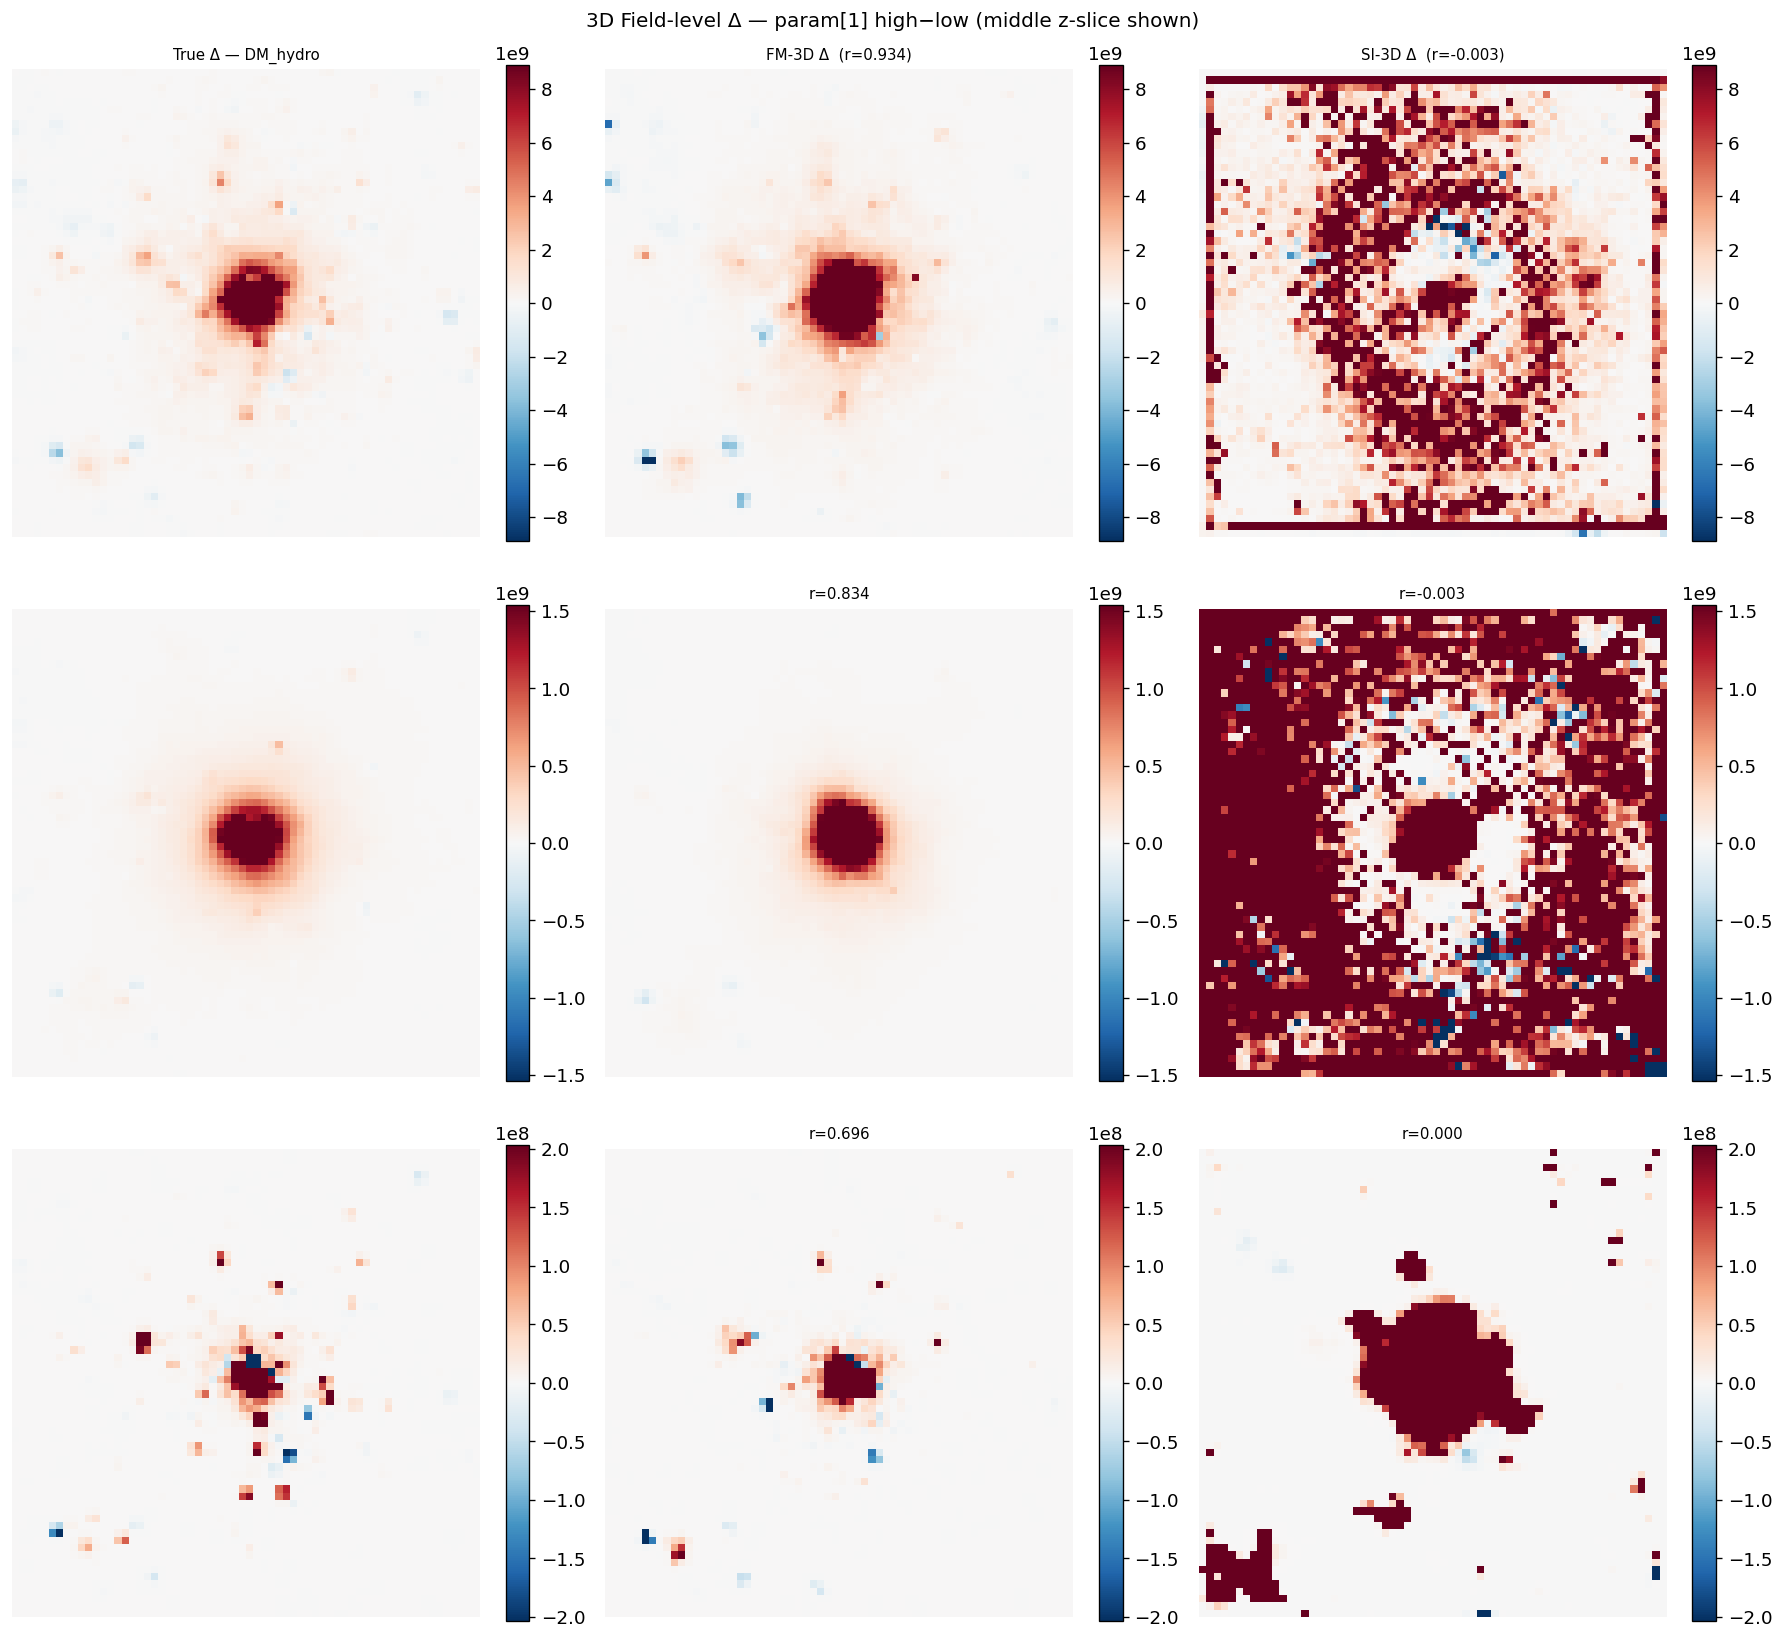

  3D correlation of Δ volumes with truth:
    DM_hydro     FM-3D: r3D = 0.0004
    DM_hydro     SI-3D: r3D = -0.0001
    Gas          FM-3D: r3D = -0.0002
    Gas          SI-3D: r3D = -0.0005
    Stars        FM-3D: r3D = 0.0800
    Stars        SI-3D: r3D = -0.0000


In [20]:
PARAM_AXES = [0, 1]
FRAC       = 0.25
N_Q        = max(5, int(len(real) * FRAC))   # ensure at least 5 volumes per group
SLICE_Z    = CROP_SIZE // 2

for p_idx in PARAM_AXES:
    p_vals = params[:, p_idx]
    order  = np.argsort(p_vals)
    lo_idx = order[:N_Q]
    hi_idx = order[-N_Q:]

    print(f'\nParam [{p_idx}]  lo: {p_vals[lo_idx].mean():.3f}  '
          f'hi: {p_vals[hi_idx].mean():.3f}  ({N_Q} volumes each)')

    n_models = len(results)
    fig, axes = plt.subplots(3, 1 + n_models, figsize=(5 * (1 + n_models), 14))

    for ch in range(3):
        # Middle slice of the mean difference volume
        delta_true = (real[hi_idx, ch].mean(0) - real[lo_idx, ch].mean(0))[SLICE_Z]
        vmax = np.percentile(np.abs(delta_true), 99)

        ax = axes[ch, 0]
        im = ax.imshow(delta_true, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
        ax.set_title(f'True Δ — {CHANNEL_NAMES[ch]}' if ch == 0 else '', fontsize=9)
        ax.set_ylabel(CHANNEL_NAMES[ch], fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

        for ri, (lbl, res) in enumerate(results.items()):
            delta_gen = (res['gen'][hi_idx, ch].mean(0) - res['gen'][lo_idx, ch].mean(0))[SLICE_Z]
            ax2 = axes[ch, ri + 1]
            im2 = ax2.imshow(delta_gen, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
            corr = np.corrcoef(delta_true.flatten(), delta_gen.flatten())[0, 1]
            ax2.set_title(f'{lbl} Δ  (r={corr:.3f})' if ch == 0 else f'r={corr:.3f}', fontsize=9)
            ax2.axis('off')
            plt.colorbar(im2, ax=ax2, fraction=0.046)

    plt.suptitle(f'3D Field-level Δ — param[{p_idx}] high−low (middle z-slice shown)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

    # 3D correlation (not just a slice)
    print(f'  3D correlation of Δ volumes with truth:')
    for ch, name in enumerate(CHANNEL_NAMES):
        delta_true_3d = real[hi_idx, ch].mean(0) - real[lo_idx, ch].mean(0)
        for lbl, res in results.items():
            delta_gen_3d = res['gen'][hi_idx, ch].mean(0) - res['gen'][lo_idx, ch].mean(0)
            r3d = np.corrcoef(delta_true_3d.flatten(), delta_gen_3d.flatten())[0, 1]
            print(f'    {name:12s} {lbl}: r3D = {r3d:.4f}')

## 7. Extra: Slice-to-Slice Variance (Stochastic Consistency)
Generate multiple samples from the same condition; measure variance across samples  
vs variance of the truth ensemble. A good model should not be overconfident (too low variance)
or underdispersed.

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

...

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

  sampling:   0%|          | 0/1 [00:00<?, ?it/s]

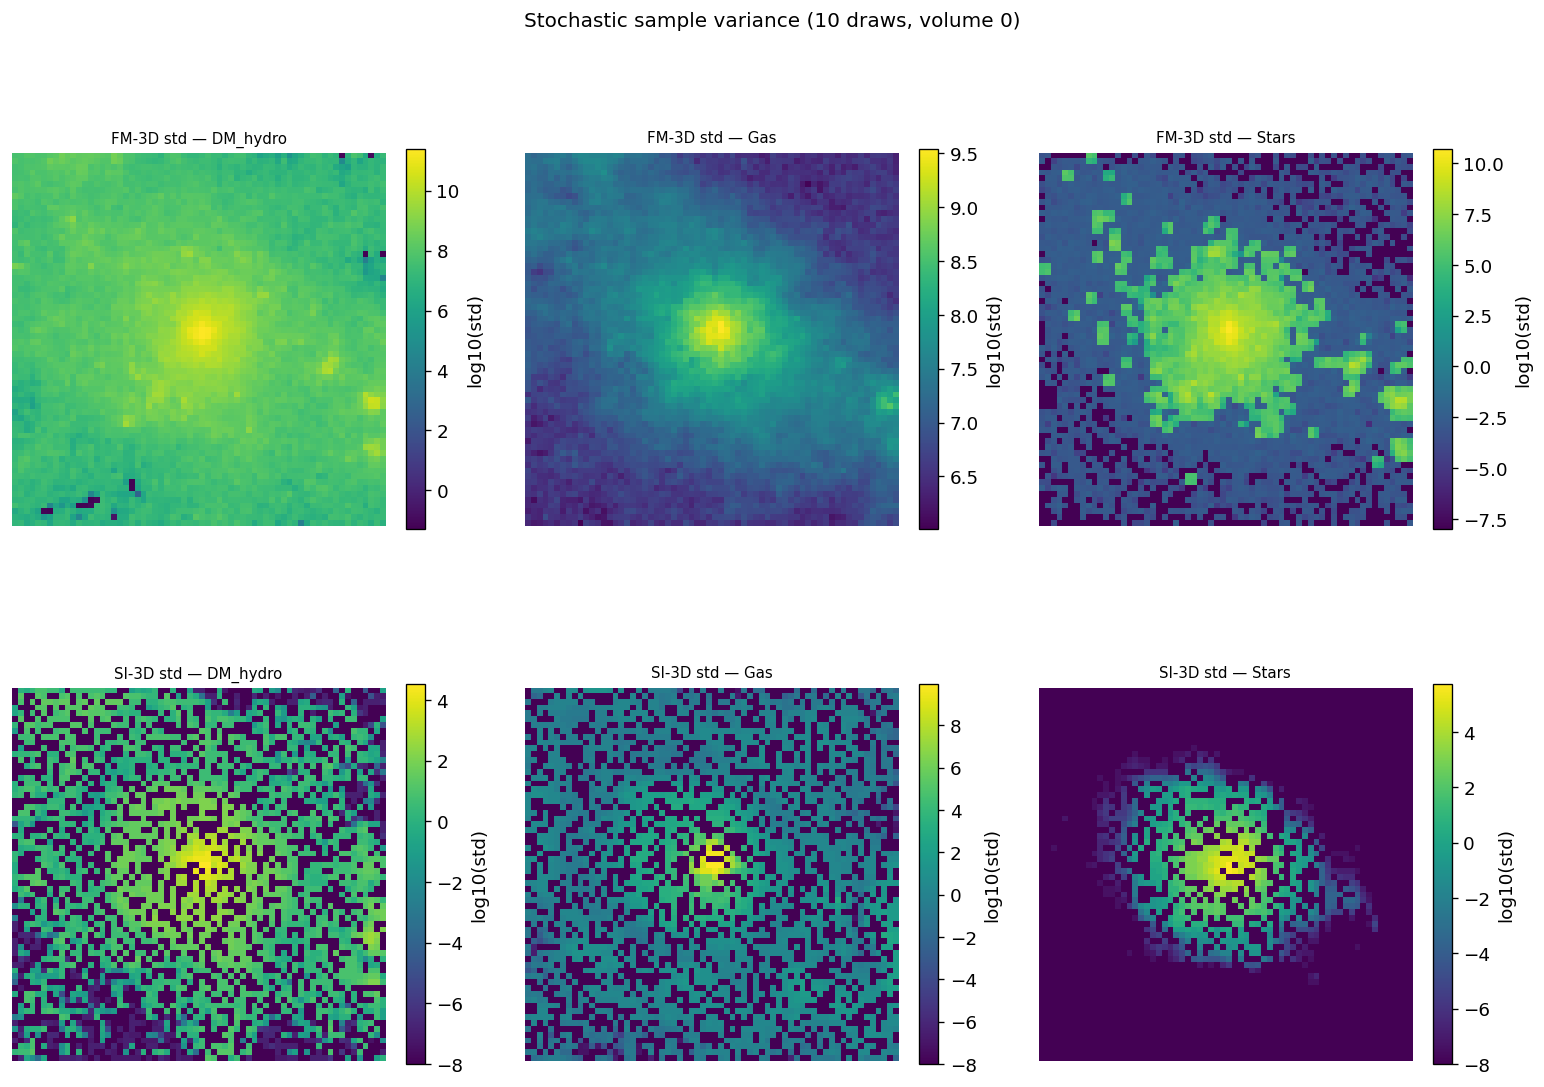

In [16]:
# Use a single test file; generate N_SAMPLES predictions from the same condition
N_SAMPLES  = 10
SAMPLE_IDX = 0   # which test volume to probe

sample_file = [test_files[SAMPLE_IDX]]

fig, axes = plt.subplots(len(results), 3, figsize=(13, 5 * len(results)))
if len(results) == 1:
    axes = axes[np.newaxis, :]

for ri, (lbl, res) in enumerate(results.items()):
    model, ns = load_run_3d(Path(RUNS_DIR) / dict(RUNS)[lbl])
    samples = []
    for _ in range(N_SAMPLES):
        _, gen_s, _ = generate_predictions_3d(model, ns, sample_file,
                                               batch_size=1, n_steps=N_STEPS,
                                               n_workers=0)
        samples.append(gen_s[0])  # (3, 64, 64, 64)
    samples = np.stack(samples)   # (N_SAMPLES, 3, 64, 64, 64)
    del model; torch.cuda.empty_cache()

    for ch in range(3):
        std_map = samples[:, ch, CROP_SIZE//2].std(0)  # pixel std across samples (middle slice)
        ax = axes[ri, ch]
        im = ax.imshow(np.log10(std_map + 1e-8), cmap='viridis', origin='lower')
        ax.set_title(f'{lbl} std — {CHANNEL_NAMES[ch]}', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, label='log10(std)')

plt.suptitle(f'Stochastic sample variance ({N_SAMPLES} draws, volume {SAMPLE_IDX})', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Numeric Summary

In [19]:
print('=' * 65)
print('NUMERIC SUMMARY — 3D model comparison')
print('=' * 65)

for lbl, res in results.items():
    gen = res['gen']
    print(f'\n── {lbl} ──')

    mass_errs, pk_errs, prof_errs = [], [], []
    for ch, name in enumerate(CHANNEL_NAMES):
        # Mass
        m_r = real[:, ch].sum(axis=(-3, -2, -1))
        m_g = gen[:,  ch].sum(axis=(-3, -2, -1))
        merr = float(np.median(np.abs((m_g - m_r) / (m_r + 1e-30))) * 100)
        mass_errs.append(merr)

        # P(k) on mean field
        k, pk_r = power_spectrum_3d(real[:, ch].mean(0), BOX_SIZE)
        _, pk_g = power_spectrum_3d(gen[:, ch].mean(0),  BOX_SIZE)
        mask = (k > 0) & (pk_r > 0)
        perr = float(np.median(np.abs(np.log10(pk_g[mask] / pk_r[mask] + 1e-10))))
        pk_errs.append(perr)

        # Radial profile error
        _, pr_m, _ = batch_profiles_3d(real[:, ch], n_bins=32)
        _, pg_m, _ = batch_profiles_3d(gen[:,  ch], n_bins=32)
        perrf = float(np.mean(np.abs(pg_m - pr_m) / (pr_m + 1e-8)))
        prof_errs.append(perrf)

        print(f'  {name:12s}  mass_err={merr:6.2f}%  '
              f'pk_log10_err={perr:.4f}  profile_relerr={perrf:.4f}')

    true_occ = (real[:, 2] > STAR_THRESH).mean() * 100
    gen_occ  = (gen[:,  2] > STAR_THRESH).mean() * 100
    print(f'  Stellar occupancy: true={true_occ:.2f}%  gen={gen_occ:.2f}%  '
          f'Δ={gen_occ - true_occ:+.2f} pp')
    print(f'  Mean mass err [%]: {np.mean(mass_errs):.2f}')
    print(f'  Mean P(k) err:     {np.mean(pk_errs):.4f}')

print('\n' + '=' * 65)

NUMERIC SUMMARY — 3D model comparison

── FM-3D ──
  DM_hydro      mass_err= 48.83%  pk_log10_err=7.0366  profile_relerr=0.3884
  Gas           mass_err= 43.39%  pk_log10_err=10.5696  profile_relerr=0.2217
  Stars         mass_err= 96.02%  pk_log10_err=2.0236  profile_relerr=4.7610
  Stellar occupancy: true=2.16%  gen=59.86%  Δ=+57.70 pp
  Mean mass err [%]: 62.75
  Mean P(k) err:     6.5432

── SI-3D ──
  DM_hydro      mass_err= 46.55%  pk_log10_err=33.9540  profile_relerr=379354493.0465
  Gas           mass_err= 39.95%  pk_log10_err=34.6876  profile_relerr=64814360738.5723
  Stars         mass_err= 92.04%  pk_log10_err=47.9541  profile_relerr=14384936523217.5488
  Stellar occupancy: true=2.16%  gen=81.38%  Δ=+79.22 pp
  Mean mass err [%]: 59.51
  Mean P(k) err:     38.8652



## 9. FM Prior-Temperature Sweep (stochasticity control)

Experiment #1 from discussion: for FM only, sample with

- $x_0 = \tau\,\epsilon$, with $\epsilon \sim \mathcal{N}(0, I)$

and sweep $\tau$ to inspect the quality-diversity tradeoff.

Interpretation guideline:

- low $\tau$: less stochasticity, potentially lower diversity
- high $\tau$: more stochasticity, potentially worse fidelity

In [28]:
@torch.no_grad()
def fm_sample_with_prior_temp(fm_obj, condition, large_scale, params,
                              n_steps=50, cfg_scale=1.0, prior_temp=1.0):
    """FM sampling with controllable prior temperature: x0 = prior_temp * N(0, I)."""
    fm_obj.model.eval()
    bsz = condition.shape[0]
    spatial = condition.shape[2:]
    device = condition.device

    x = torch.randn(bsz, 3, *spatial, device=device) * prior_temp
    dt = 1.0 / n_steps

    for i in range(n_steps):
        t = torch.full((bsz,), i * dt, device=device)
        inp = torch.cat([x, condition, large_scale], dim=1)

        if cfg_scale != 1.0:
            v_cond = fm_obj.model(inp, t, params)
            v_uncond = fm_obj.model(inp, t, torch.zeros_like(params))
            v = v_uncond + cfg_scale * (v_cond - v_uncond)
        else:
            v = fm_obj.model(inp, t, params)

        x = x + v * dt

    return x


def denorm_3d(fields_norm, ns):
    """Undo norm + log10(1+x) transform for arrays of shape (N,3,D,H,W)."""
    out = fields_norm.copy()
    for ch in range(3):
        out[:, ch] = out[:, ch] * ns.target_std[ch] + ns.target_mean[ch]
        out[:, ch] = 10.0 ** out[:, ch] - 1.0
    return np.clip(out, 0, None)

--- FM prior-temperature sweep (single condition) ---
Sample index: 0 | draws per tau: 6
Per-tau mean±std of total mass across stochastic draws:
  tau=0.0 | DM_hydro: 1.521e+14±0.000e+00 | Gas: 7.123e+13±8.389e+06 | Stars: 4.021e+13±0.000e+00 | StarOcc: 4.23%±0.00%
  tau=0.5 | DM_hydro: 6.227e+13±3.696e+12 | Gas: 2.673e+13±1.826e+12 | Stars: 3.905e+12±1.730e+12 | StarOcc: 4.21%±0.20%
  tau=1.0 | DM_hydro: 4.400e+15±8.543e+15 | Gas: 1.392e+14±1.999e+14 | Stars: 5.833e+11±4.724e+11 | StarOcc: 2.29%±0.08%
  tau=1.5 | DM_hydro: 3.166e+22±inf | Gas: 2.488e+17±3.888e+17 | Stars: 2.955e+12±4.527e+12 | StarOcc: 59.65%±6.98%
  tau=2.0 | DM_hydro: 9.051e+20±inf | Gas: 1.065e+24±inf | Stars: 1.224e+12±7.040e+11 | StarOcc: 76.09%±1.48%


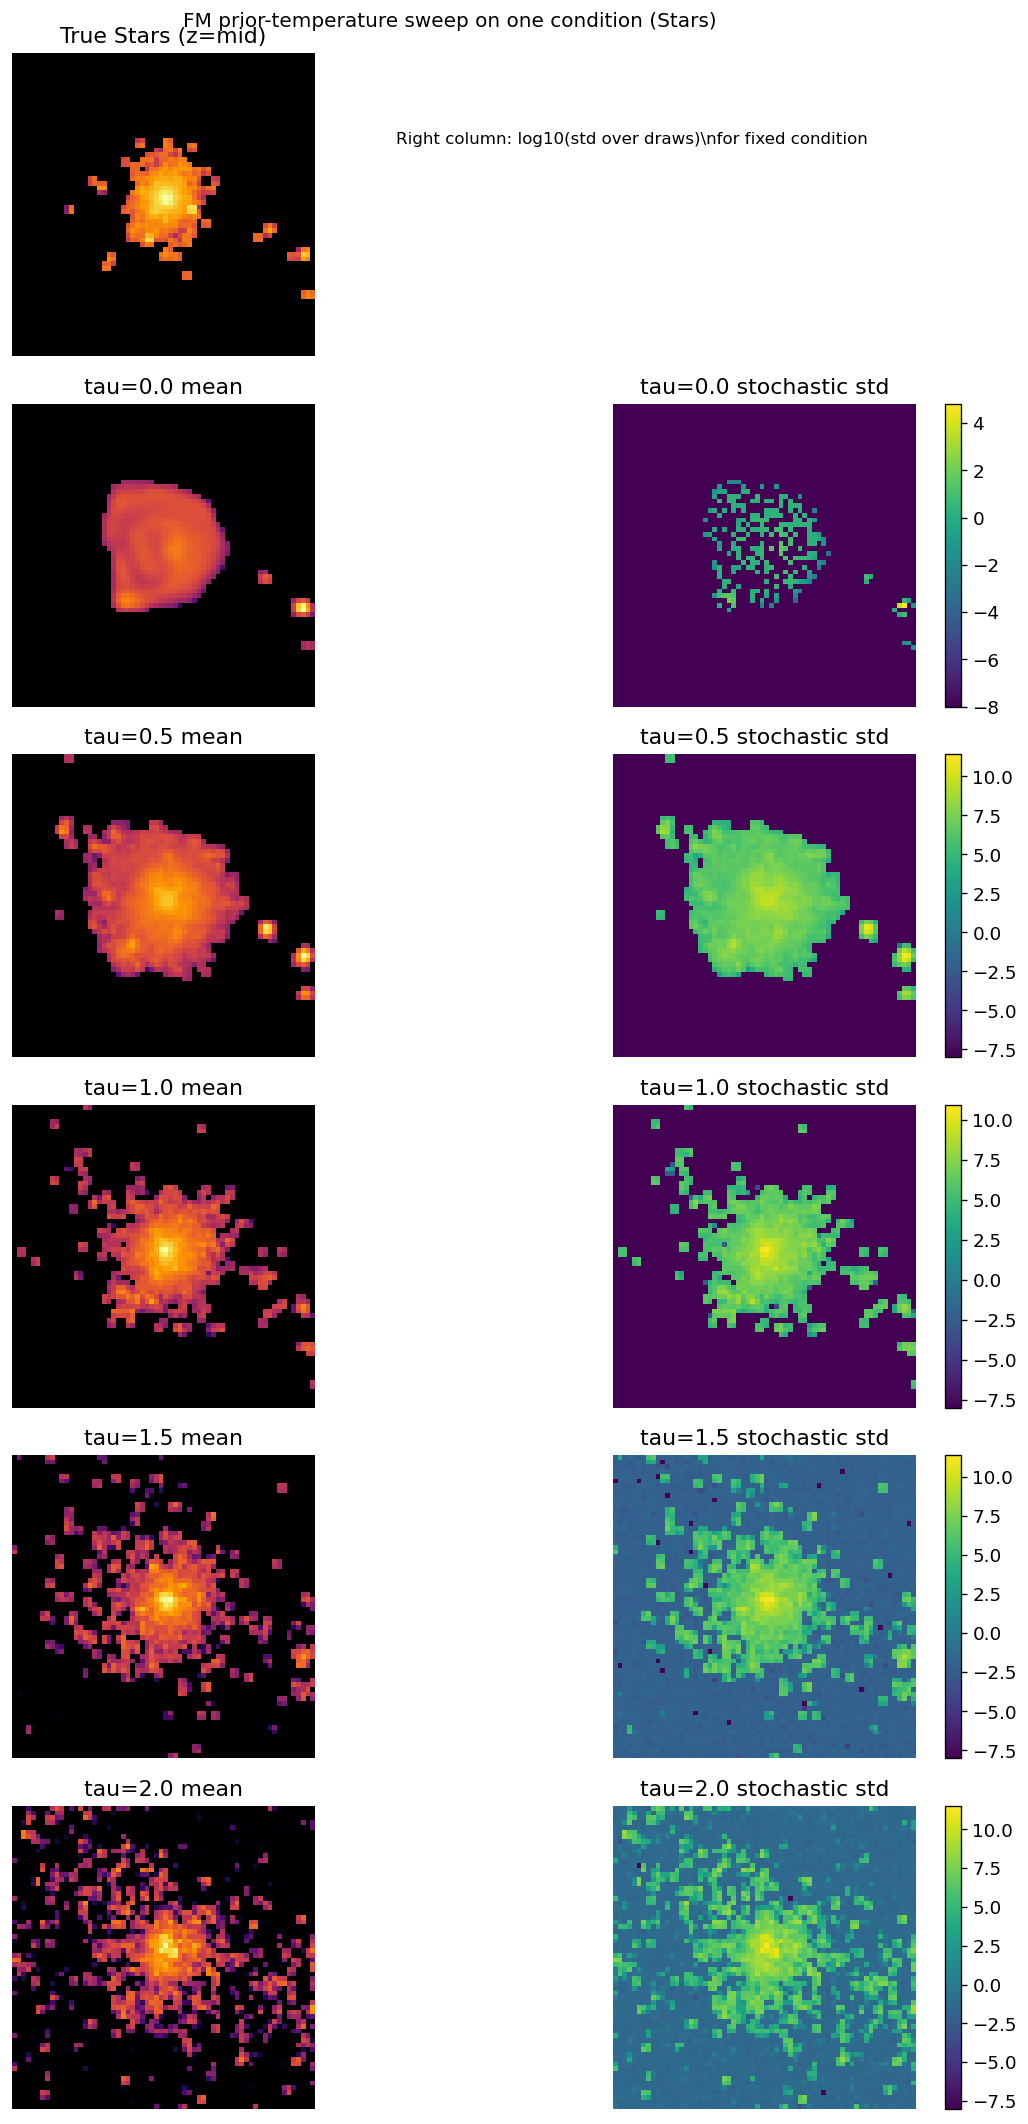

In [ ]:
# Sweep prior temperature on a single FM-conditioned volume and inspect diversity/fidelity.
TEMP_FM_RUN = RUNS_DIR / FM_RUN_NAME
TEMP_GRID = [0.0, 0.5, 1.0, 1.5, 2.0]
N_DRAWS_PER_TEMP = 6
EXP_SAMPLE_IDX = 0
EXP_CHANNEL = 2  # Stars

fm_model, fm_ns = load_run_3d(TEMP_FM_RUN)

# One deterministic condition from the held-out set
exp_ds = AstroDataset3D([test_files[EXP_SAMPLE_IDX]], fm_ns,
                        crop_size=CROP_SIZE, random_crop=False, augment_flip=False)
exp_batch = exp_ds[0]

cond_t = exp_batch['condition'][None].to(device)
ls_t = exp_batch['large_scale'][None].to(device)
params_t = exp_batch['params'][None].to(device)
true_phys = denorm_3d(exp_batch['target'][None].numpy().copy(), fm_ns)[0]

samples_by_temp = {}
for tau in TEMP_GRID:
    draws = []
    for draw_idx in range(N_DRAWS_PER_TEMP):
        # Change RNG state per draw while keeping reproducibility.
        torch.manual_seed(SEED + int(100 * tau) + 1000 * draw_idx)
        gen_norm = fm_sample_with_prior_temp(
            fm_model.fm, cond_t, ls_t, params_t,
            n_steps=N_STEPS, prior_temp=tau
        )
        gen_phys = denorm_3d(gen_norm.float().cpu().numpy(), fm_ns)[0]
        draws.append(gen_phys)
    samples_by_temp[tau] = np.stack(draws)

# ---- Numeric summary ----
print('--- FM prior-temperature sweep (single condition) ---')
print(f'Sample index: {EXP_SAMPLE_IDX} | draws per tau: {N_DRAWS_PER_TEMP}')
print('Per-tau mean±std of total mass across stochastic draws:')
for tau in TEMP_GRID:
    arr = samples_by_temp[tau]  # (n_draws, 3, D, H, W)
    msg = [f'  tau={tau:>3.1f}']
    for ch, name in enumerate(CHANNEL_NAMES):
        m = arr[:, ch].sum(axis=(-3, -2, -1))
        msg.append(f'{name}: {m.mean():.3e}±{m.std():.3e}')
    occ = (arr[:, 2] > STAR_THRESH).mean(axis=(1, 2, 3)) * 100
    msg.append(f'StarOcc: {occ.mean():.2f}%±{occ.std():.2f}%')
    print(' | '.join(msg))

# ---- Visual summary (mean and stochastic std maps) ----
mid = CROP_SIZE // 2
n_rows = len(TEMP_GRID) + 1
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3 * n_rows))

axes[0, 0].imshow(np.log10(true_phys[EXP_CHANNEL, mid] + 1), cmap='inferno', origin='lower')
axes[0, 0].set_title(f'True {CHANNEL_NAMES[EXP_CHANNEL]} (z=mid)')
axes[0, 0].axis('off')
axes[0, 1].axis('off')
axes[0, 1].text(0.02, 0.7, 'Right column: log10(std over draws)\\nfor fixed condition', fontsize=10)

for r, tau in enumerate(TEMP_GRID, start=1):
    arr = samples_by_temp[tau][:, EXP_CHANNEL]  # (draws, D, H, W)
    mean_map = arr.mean(axis=0)[mid]
    std_map = arr.std(axis=0)[mid]

    axes[r, 0].imshow(np.log10(mean_map + 1), cmap='inferno', origin='lower')
    axes[r, 0].set_title(f'tau={tau:.1f} mean')
    axes[r, 0].axis('off')

    im = axes[r, 1].imshow(np.log10(std_map + 1e-8), cmap='viridis', origin='lower')
    axes[r, 1].set_title(f'tau={tau:.1f} stochastic std')
    axes[r, 1].axis('off')
    plt.colorbar(im, ax=axes[r, 1], fraction=0.046)

plt.suptitle(f'FM prior-temperature sweep on one condition ({CHANNEL_NAMES[EXP_CHANNEL]})', fontsize=12)
plt.tight_layout()
plt.show()

del fm_model
torch.cuda.empty_cache()

## 10. FM Temperature Selection Mini-Benchmark (N=32)

This evaluates FM prior temperature on a held-out subset and reports aggregate fidelity and stability metrics.

We score each temperature with:

- mean mass error across channels
- mean mean-field power-spectrum error across channels
- mean radial-profile error across channels
- absolute stellar-occupancy drift
- non-finite/clipping diagnostics

--- FM temperature mini-benchmark ---
Evaluating 32 held-out volumes | temps=[0.0, 0.25, 0.5, 0.75, 1.0]


  tau=0.00:   0%|          | 0/16 [00:00<?, ?it/s]

  tau=0.25:   0%|          | 0/16 [00:00<?, ?it/s]

  tau=0.50:   0%|          | 0/16 [00:00<?, ?it/s]

  tau=0.75:   0%|          | 0/16 [00:00<?, ?it/s]

  tau=1.00:   0%|          | 0/16 [00:00<?, ?it/s]


Ranked temperatures (lower score is better):
tau    score    mass%    pk_err    prof_err   occ_delta(pp)  nonfinite%  clipped%
0.75  0.070    97.14    0.895     1.421      0.42           0.000       0.000   
0.50  0.731    383.10   0.899     4.948      1.33           0.000       0.001   
1.00  1.475    28.26    1.125     0.437      2.98           0.000       0.001   
0.25  3.016    1173.15  1.364     19.375     2.14           0.000       0.003   
0.00  4.075    1678.22  1.402     35.895     1.89           0.000       0.008   

Recommended default prior temperature from this mini-benchmark: tau=0.75


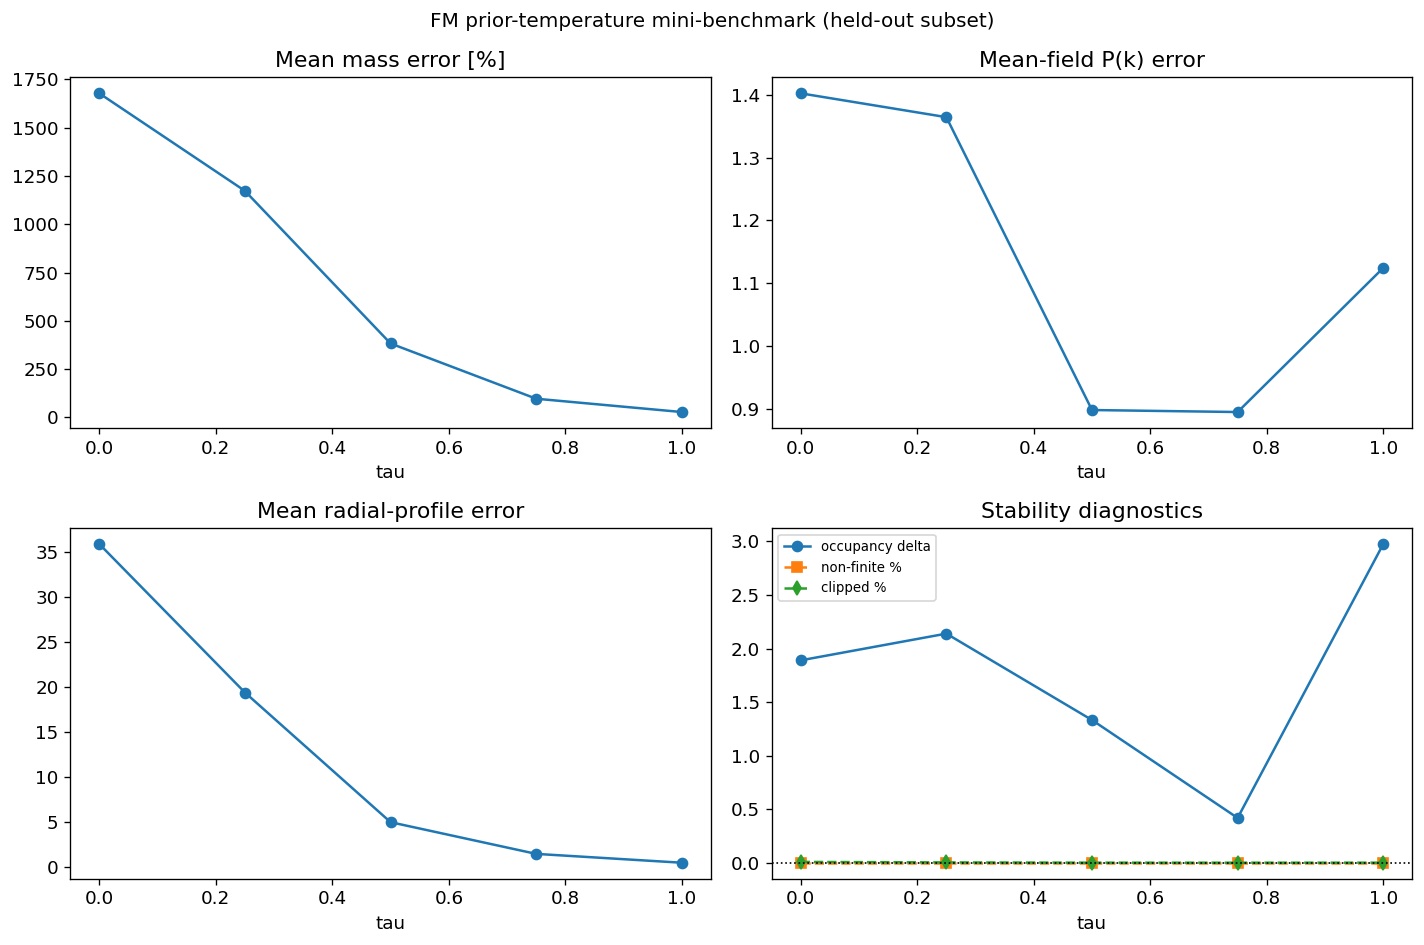

In [ ]:
# Batch-level FM prior-temperature benchmark on held-out conditions.
TAU_GRID_BENCH = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EVAL_TAU = min(32, len(test_files))
BENCH_BATCH_SIZE = 2
BENCH_N_STEPS = N_STEPS
BENCH_BINS = 32

bench_rng = np.random.RandomState(SEED + 2026)
bench_idx = bench_rng.choice(len(test_files), N_EVAL_TAU, replace=False)
bench_files = [test_files[i] for i in bench_idx]

fm_model_bench, fm_ns_bench = load_run_3d(RUNS_DIR / FM_RUN_NAME)
bench_ds = AstroDataset3D(
    bench_files, fm_ns_bench,
    crop_size=CROP_SIZE, random_crop=False, augment_flip=False,
 )
bench_loader = DataLoader(
    bench_ds, batch_size=BENCH_BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True,
    persistent_workers=(N_WORKERS > 0),
)


def _sanitize_generated(gen_phys, clip_max):
    nonfinite_pct = float((~np.isfinite(gen_phys)).mean() * 100)
    gen_safe = np.nan_to_num(gen_phys, nan=0.0, posinf=clip_max, neginf=0.0)
    clipped_pct = float((gen_safe >= clip_max).mean() * 100)
    gen_safe = np.clip(gen_safe, 0.0, clip_max)
    return gen_safe, nonfinite_pct, clipped_pct


def _aggregate_metrics(real_arr, gen_arr):
    mass_errs, pk_errs, prof_errs = [], [], []

    for ch in range(3):
        # Mass error
        m_r = real_arr[:, ch].sum(axis=(-3, -2, -1))
        m_g = gen_arr[:, ch].sum(axis=(-3, -2, -1))
        merr = float(np.median(np.abs((m_g - m_r) / (m_r + 1e-30))) * 100)
        mass_errs.append(merr)

        # Mean-field P(k) error
        k, pk_r = power_spectrum_3d(real_arr[:, ch].mean(0), BOX_SIZE)
        _, pk_g = power_spectrum_3d(gen_arr[:, ch].mean(0), BOX_SIZE)
        mask = (k > 0) & (pk_r > 0) & (pk_g > 0) & np.isfinite(pk_r) & np.isfinite(pk_g)
        perr = float(np.median(np.abs(np.log10(pk_g[mask] / pk_r[mask])))) if mask.any() else np.nan
        pk_errs.append(perr)

        # Radial profile error
        _, pr_m, _ = batch_profiles_3d(real_arr[:, ch], n_bins=BENCH_BINS)
        _, pg_m, _ = batch_profiles_3d(gen_arr[:, ch], n_bins=BENCH_BINS)
        perrf = float(np.mean(np.abs(pg_m - pr_m) / (pr_m + 1e-8)))
        prof_errs.append(perrf)

    true_occ = float((real_arr[:, 2] > STAR_THRESH).mean() * 100)
    gen_occ = float((gen_arr[:, 2] > STAR_THRESH).mean() * 100)

    return {
        'mean_mass_err': float(np.mean(mass_errs)),
        'mean_pk_err': float(np.nanmean(pk_errs)),
        'mean_profile_err': float(np.mean(prof_errs)),
        'true_occ': true_occ,
        'gen_occ': gen_occ,
        'occ_delta': float(gen_occ - true_occ),
    }


bench_rows = []
print('--- FM temperature mini-benchmark ---')
print(f'Evaluating {N_EVAL_TAU} held-out volumes | temps={TAU_GRID_BENCH}')

for tau in TAU_GRID_BENCH:
    real_batches, gen_batches = [], []
    nonfinite_pcts, clipped_pcts = [], []

    for bidx, batch in enumerate(tqdm(bench_loader, desc=f'  tau={tau:.2f}', leave=False)):
        cond = batch['condition'].to(device)
        ls = batch['large_scale'].to(device)
        pars = batch['params'].to(device)

        # Reproducible but tau-specific random draws.
        torch.manual_seed(SEED + int(1000 * tau) + bidx)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            gen_norm = fm_sample_with_prior_temp(
                fm_model_bench.fm, cond, ls, pars,
                n_steps=BENCH_N_STEPS, prior_temp=tau,
            )

        real_phys = denorm_3d(batch['target'].numpy().copy(), fm_ns_bench)
        gen_phys = denorm_3d(gen_norm.float().cpu().numpy(), fm_ns_bench)

        # Guard against overflow at high temperatures while preserving instability diagnostics.
        clip_max = float(max(1e8, np.percentile(real_phys, 99.99) * 10.0))
        gen_safe, nf_pct, cl_pct = _sanitize_generated(gen_phys, clip_max)

        real_batches.append(real_phys)
        gen_batches.append(gen_safe)
        nonfinite_pcts.append(nf_pct)
        clipped_pcts.append(cl_pct)

    real_tau = np.concatenate(real_batches, axis=0)
    gen_tau = np.concatenate(gen_batches, axis=0)

    metrics = _aggregate_metrics(real_tau, gen_tau)
    metrics['tau'] = tau
    metrics['nonfinite_pct'] = float(np.mean(nonfinite_pcts))
    metrics['clipped_pct'] = float(np.mean(clipped_pcts))
    bench_rows.append(metrics)


def _norm01(x):
    x = np.asarray(x, dtype=np.float64)
    lo, hi = np.nanmin(x), np.nanmax(x)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(x)
    return (x - lo) / (hi - lo)


# Composite score: lower is better.
mass_v = np.array([r['mean_mass_err'] for r in bench_rows])
pk_v = np.array([r['mean_pk_err'] for r in bench_rows])
prof_v = np.array([r['mean_profile_err'] for r in bench_rows])
occ_v = np.array([abs(r['occ_delta']) for r in bench_rows])
nf_v = np.array([r['nonfinite_pct'] for r in bench_rows])
clip_v = np.array([r['clipped_pct'] for r in bench_rows])

score = (
    _norm01(mass_v)
    + _norm01(pk_v)
    + _norm01(prof_v)
    + _norm01(occ_v)
    + 0.5 * _norm01(nf_v)
    + 0.5 * _norm01(clip_v)
)

for i, r in enumerate(bench_rows):
    r['score'] = float(score[i])

bench_rows = sorted(bench_rows, key=lambda d: d['score'])

print('\nRanked temperatures (lower score is better):')
print('tau    score    mass%    pk_err    prof_err   occ_delta(pp)  nonfinite%  clipped%')
for r in bench_rows:
    print(
        f"{r['tau']:<4.2f}  {r['score']:<7.3f}  {r['mean_mass_err']:<7.2f}  "
        f"{r['mean_pk_err']:<8.3f}  {r['mean_profile_err']:<9.3f}  "
        f"{r['occ_delta']:<13.2f}  {r['nonfinite_pct']:<10.3f}  {r['clipped_pct']:<8.3f}"
    )

best_tau = bench_rows[0]['tau']
print(f"\nRecommended default prior temperature from this mini-benchmark: tau={best_tau:.2f}")

# Quick metric-vs-tau plot (use original order).
bench_rows_tau = sorted(bench_rows, key=lambda d: d['tau'])
xt = [r['tau'] for r in bench_rows_tau]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(xt, [r['mean_mass_err'] for r in bench_rows_tau], 'o-')
axes[0, 0].set_title('Mean mass error [%]')
axes[0, 0].set_xlabel('tau')

axes[0, 1].plot(xt, [r['mean_pk_err'] for r in bench_rows_tau], 'o-')
axes[0, 1].set_title('Mean-field P(k) error')
axes[0, 1].set_xlabel('tau')

axes[1, 0].plot(xt, [r['mean_profile_err'] for r in bench_rows_tau], 'o-')
axes[1, 0].set_title('Mean radial-profile error')
axes[1, 0].set_xlabel('tau')

axes[1, 1].plot(xt, [r['occ_delta'] for r in bench_rows_tau], 'o-', label='occupancy delta')
axes[1, 1].plot(xt, [r['nonfinite_pct'] for r in bench_rows_tau], 's--', label='non-finite %')
axes[1, 1].plot(xt, [r['clipped_pct'] for r in bench_rows_tau], 'd--', label='clipped %')
axes[1, 1].axhline(0.0, color='k', lw=1, ls=':')
axes[1, 1].set_title('Stability diagnostics')
axes[1, 1].set_xlabel('tau')
axes[1, 1].legend(fontsize=8)

plt.suptitle('FM prior-temperature mini-benchmark (held-out subset)', fontsize=12)
plt.tight_layout()
plt.show()

del fm_model_bench
torch.cuda.empty_cache()